# Лекция 3. Учимся без модели: TD, Q-learning и SARSA

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/IlyaChichkanov/Reinforcement-learning/blob/main/03-value-based/lecture/lecture.ipynb)

**Главный вопрос сегодня: как найти $Q^*$, если таблиц $p$ и $r$ нет, а есть только `env.step`?**

На прошлой лекции всё считалось по модели среды. Сегодня модель убираем — и оказывается, что меняется совсем немного. Нового три идеи, каждая в одну строку:

1. **Среднее на ходу.** Оценку не пересчитывают заново, а чуть сдвигают к каждому новому наблюдению.
2. **Одна попытка вместо всех исходов.** В уравнении Беллмана сумму по $s'$ заменяет переход, который реально случился.
3. **Чью стратегию учим.** Отсюда два алгоритма — Q-learning и SARSA.

Всё остальное — повторение лекций 1 и 2.

| | Раздел | Минут |
|---|---|---|
| 1 | 🔁 Вспоминаем: что такое ценность | 20 |
| 2 | Policy iteration: оценил — улучшил — повторил | 10 |
| 3 | Модели нет: что остаётся | 5 |
| 4 | Среднее на ходу | 7 |
| 5 | Монте-Карло и TD: учимся по дороге | 13 |
| 6 | Q-learning | 16 |
| 7 | SARSA и прогулка по обрыву | 15 |
| 8 | ⏱ Expected SARSA и Double Q-learning | 6 |
| 9 | Итоги | 5 |

Пометки: **🔁** — вспоминаем пройденное, **⏱** — резерв, если останется время, **📖** — для любознательных. Служебный код лежит в `gridworld.py` и `gridworld_plots.py` (из лекции 2) и в `td_plots.py`; читать его не нужно.

In [1]:
# Служебные модули: клетчатый мир из лекции 2 и картинки этой лекции.
# Локально они уже лежат в репозитории, в Google Colab — скачиваются.
import pathlib, sys, urllib.request
sys.path.append("../../02-environments/lecture")
REPO = "https://raw.githubusercontent.com/IlyaChichkanov/Reinforcement-learning/main/"
for path in ["02-environments/lecture/gridworld.py", "02-environments/lecture/gridworld_plots.py",
             "03-value-based/lecture/td_plots.py"]:
    name = pathlib.Path(path).name
    if not pathlib.Path(name).exists() and not pathlib.Path("../..", path).exists():
        urllib.request.urlretrieve(REPO + path, name)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from gridworld import *          # GridWorld, mdp_matrices, solve_q_star, greedy_policy, uniform_policy, run_episode, average_return, GAMMA
from gridworld_plots import *    # plot_values, plot_q, draw_policy, draw_transitions
from td_plots import *           # draw_cliff, greedy_path, plot_curves

env = GridWorld()                # мир лекции 2: 3 × 4, ветер 0.8 / 0.1 / 0.1, −0.04 за шаг
P, R = mdp_matrices(env)         # модель среды — сегодня только чтобы проверять ответы
Q_star = solve_q_star(P, R)      # эталон из лекции 2
V_star = Q_star.max(axis=1)
CELLS = [s for s in range(env.n_states) if not env.is_wall(s) and not env.is_terminal(s)]   # 9 клеток, где агент выбирает

## 1. 🔁 Вспоминаем: что такое ценность

### 1.1 V и Q на картинках

Return из лекции 1 — сумма наград за эпизод, где дальние награды обесценены множителем $\gamma$. Из-за ветра эпизоды получаются разными, и return тоже. Поэтому **ценность — это средний return**.

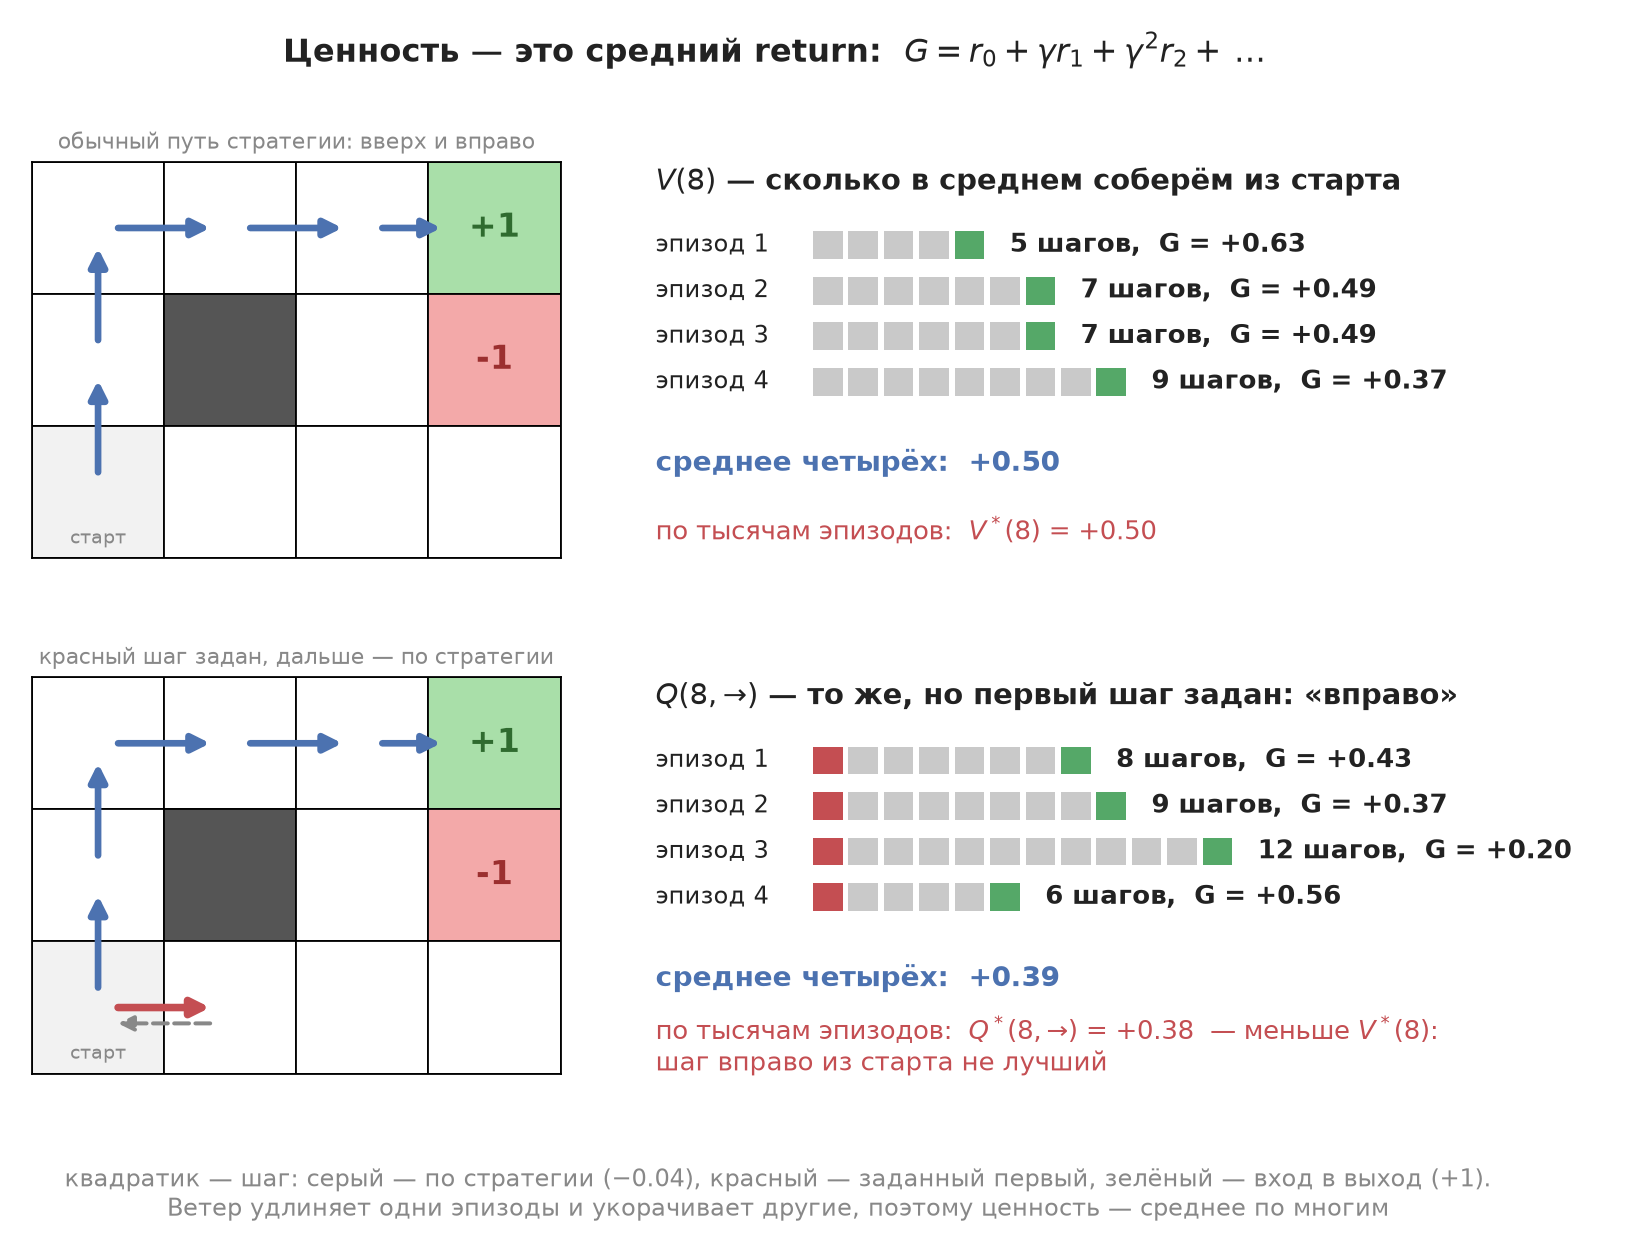

* $V(s)$ — сколько в среднем соберём, начав в клетке $s$.
* $Q(s, a)$ — то же самое, но первый шаг $a$ задан, а дальше играем как обычно.

В каждой клетке одно число $V$ и четыре числа $Q$ — по одному на действие:

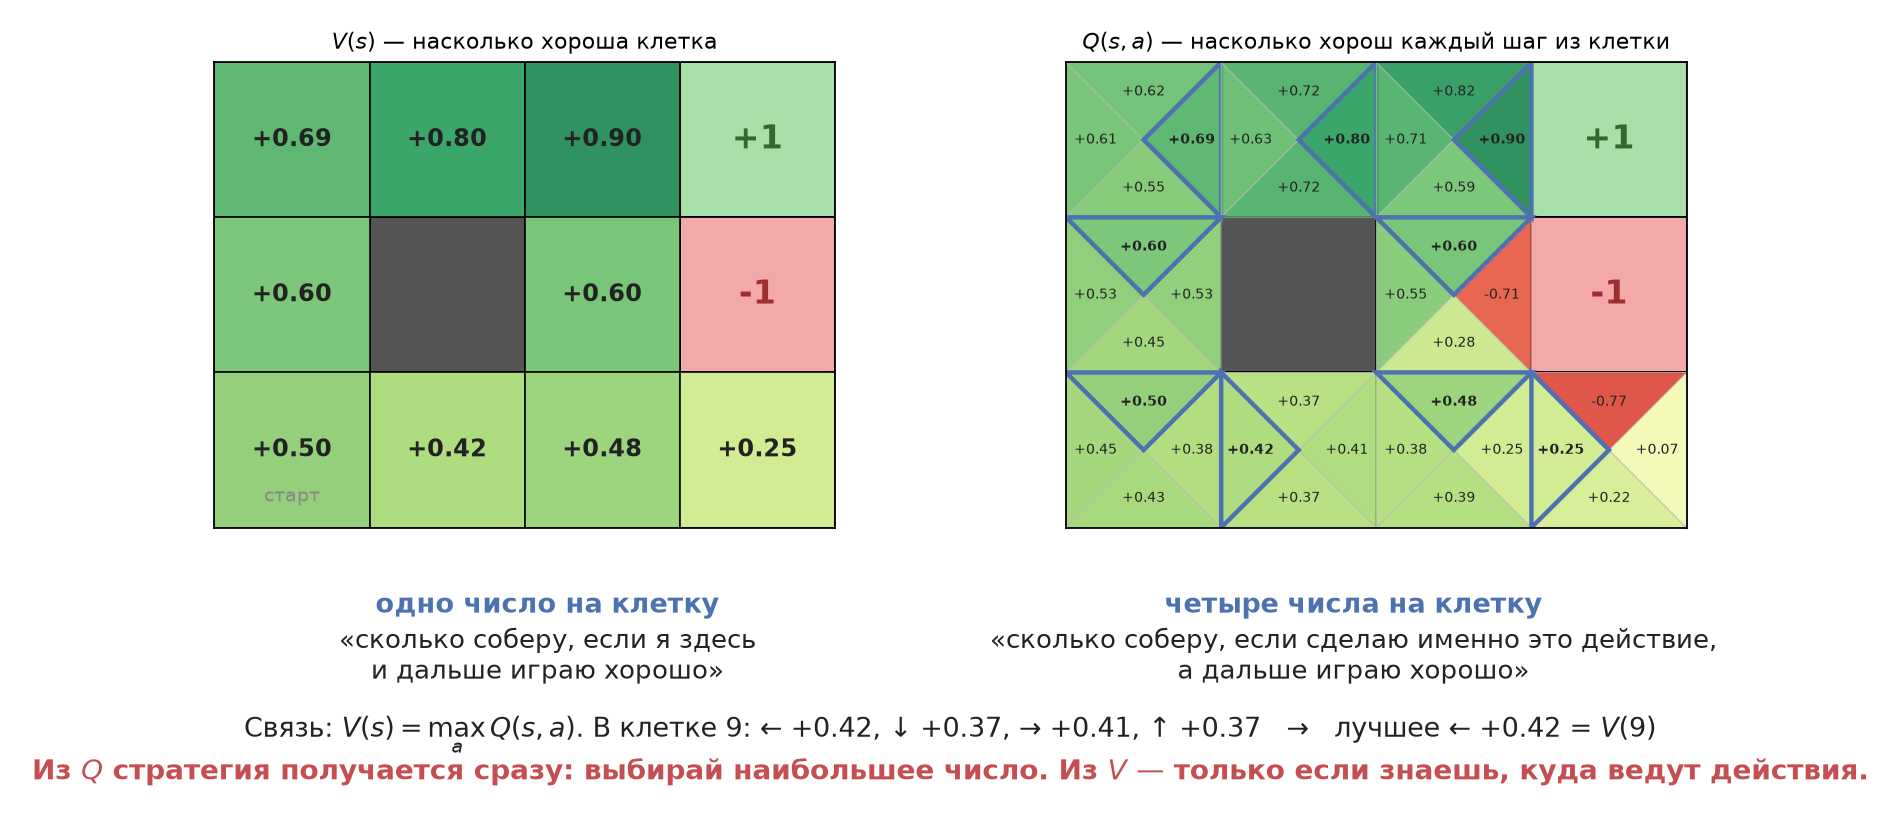

Из $Q$ стратегия получается сразу: в клетке выбираем наибольшее из четырёх чисел. Из $V$ — нет: чтобы понять, куда ведёт действие, нужна модель среды. Поэтому все сегодняшние алгоритмы учат $Q$.

### 1.2 Ценность зависит от стратегии — и от среды

Ценность всегда считается для какой-то стратегии: «сколько соберём, если дальше играть **вот так**». $V^\pi$ и $Q^\pi$ — для заданной стратегии $\pi$, например «бросаю кубик». $V^*$ и $Q^*$ — для лучшей. Сравним четыре случая: две стратегии в двух мирах — с ветром и без.

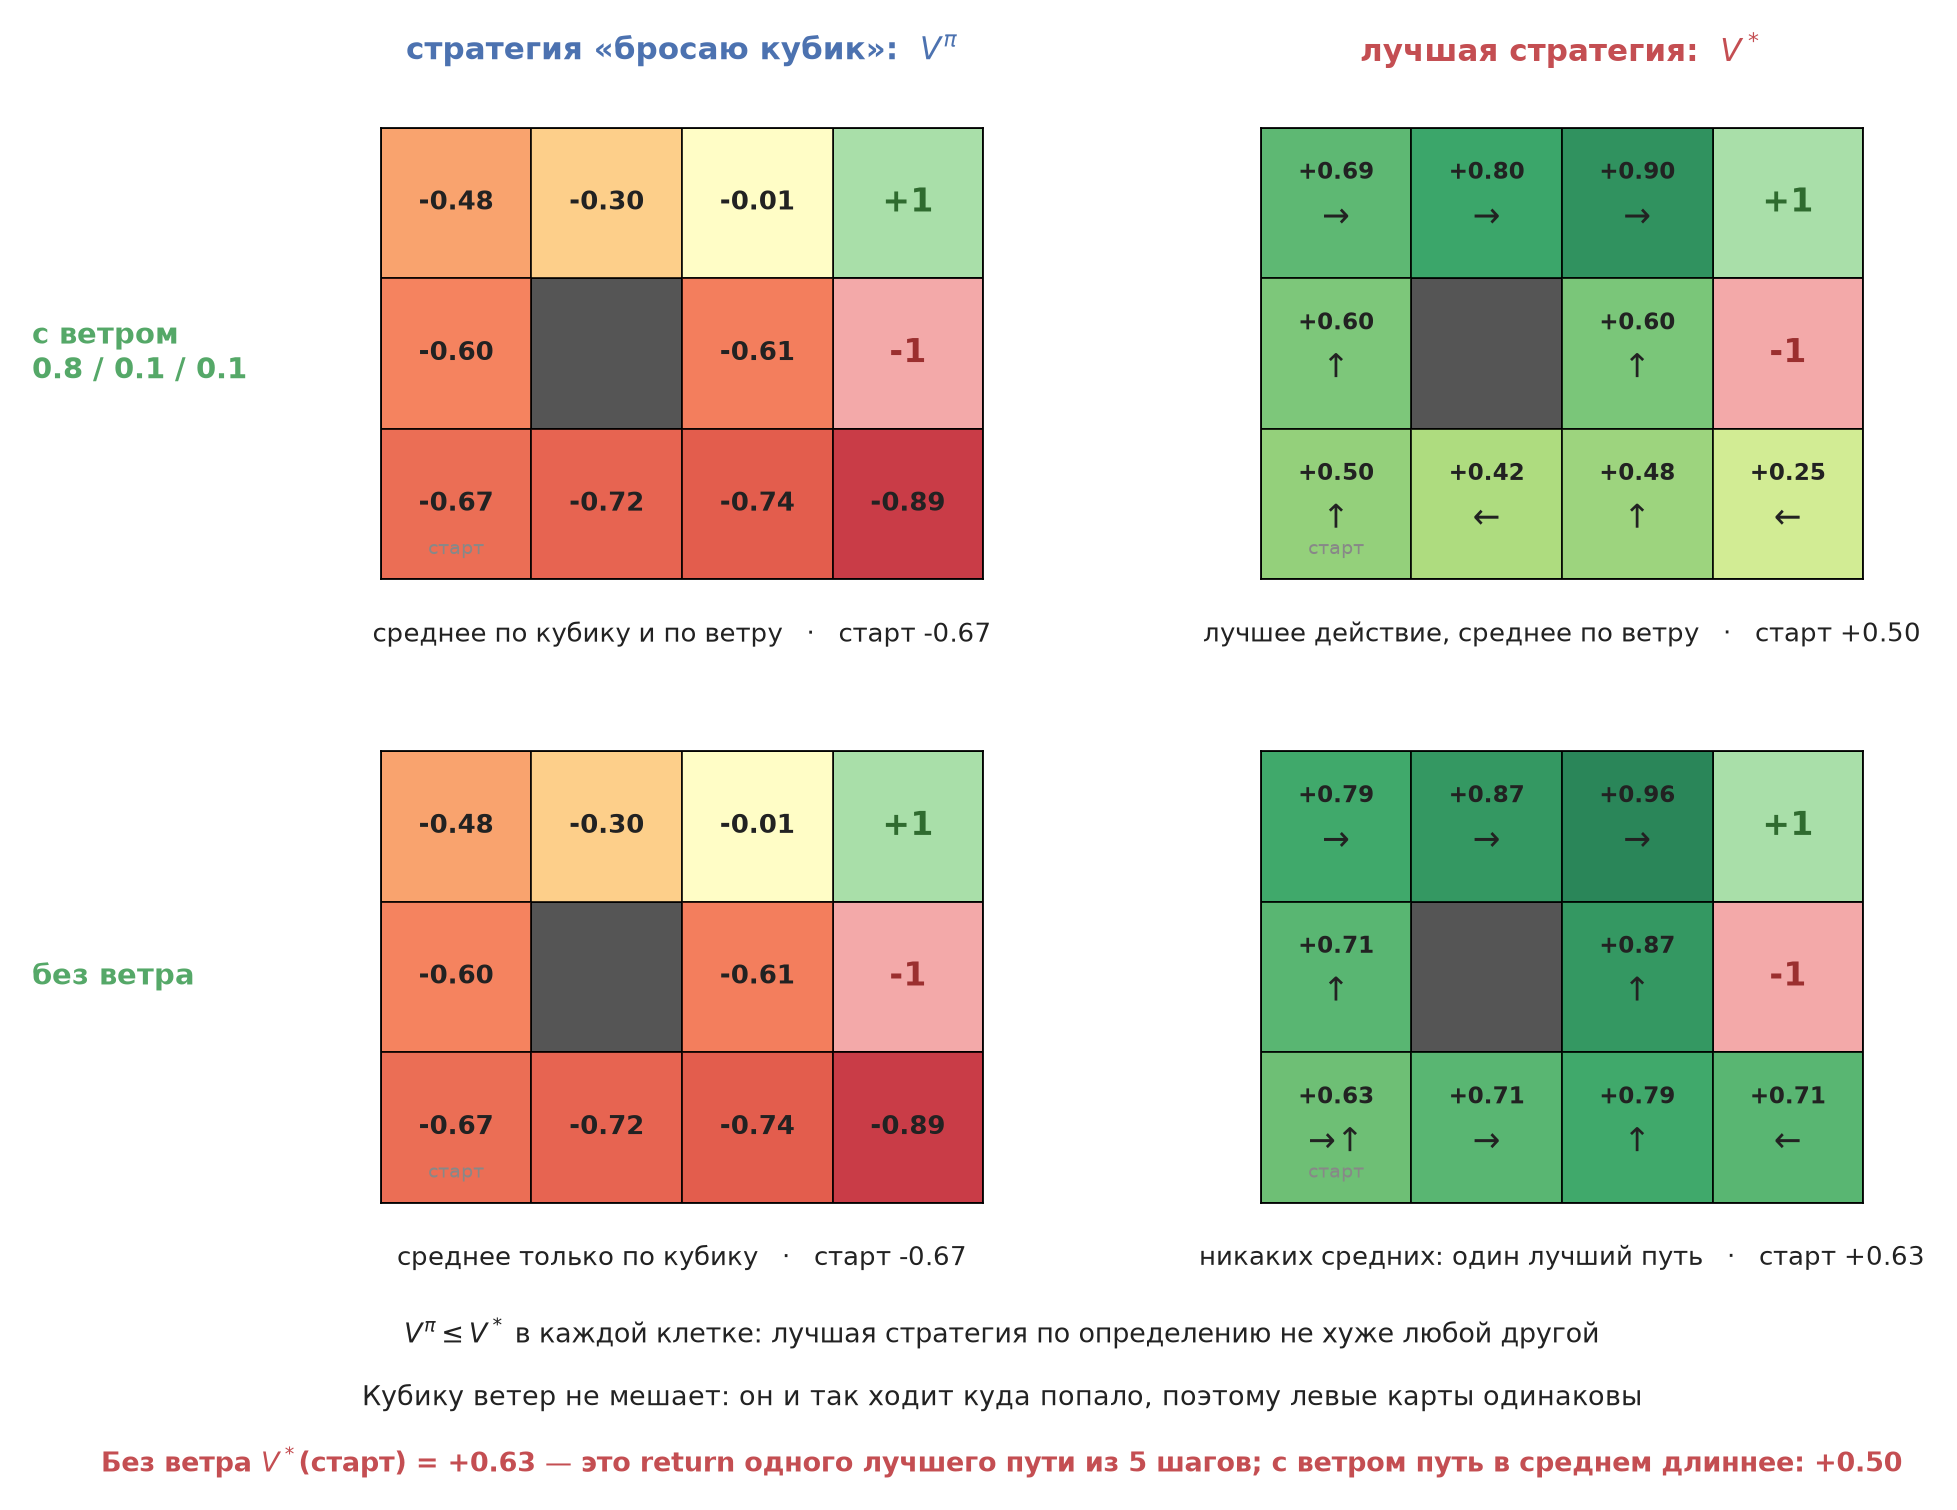

Откуда разница, видно по тому, где в уравнении стоит среднее, а где максимум:

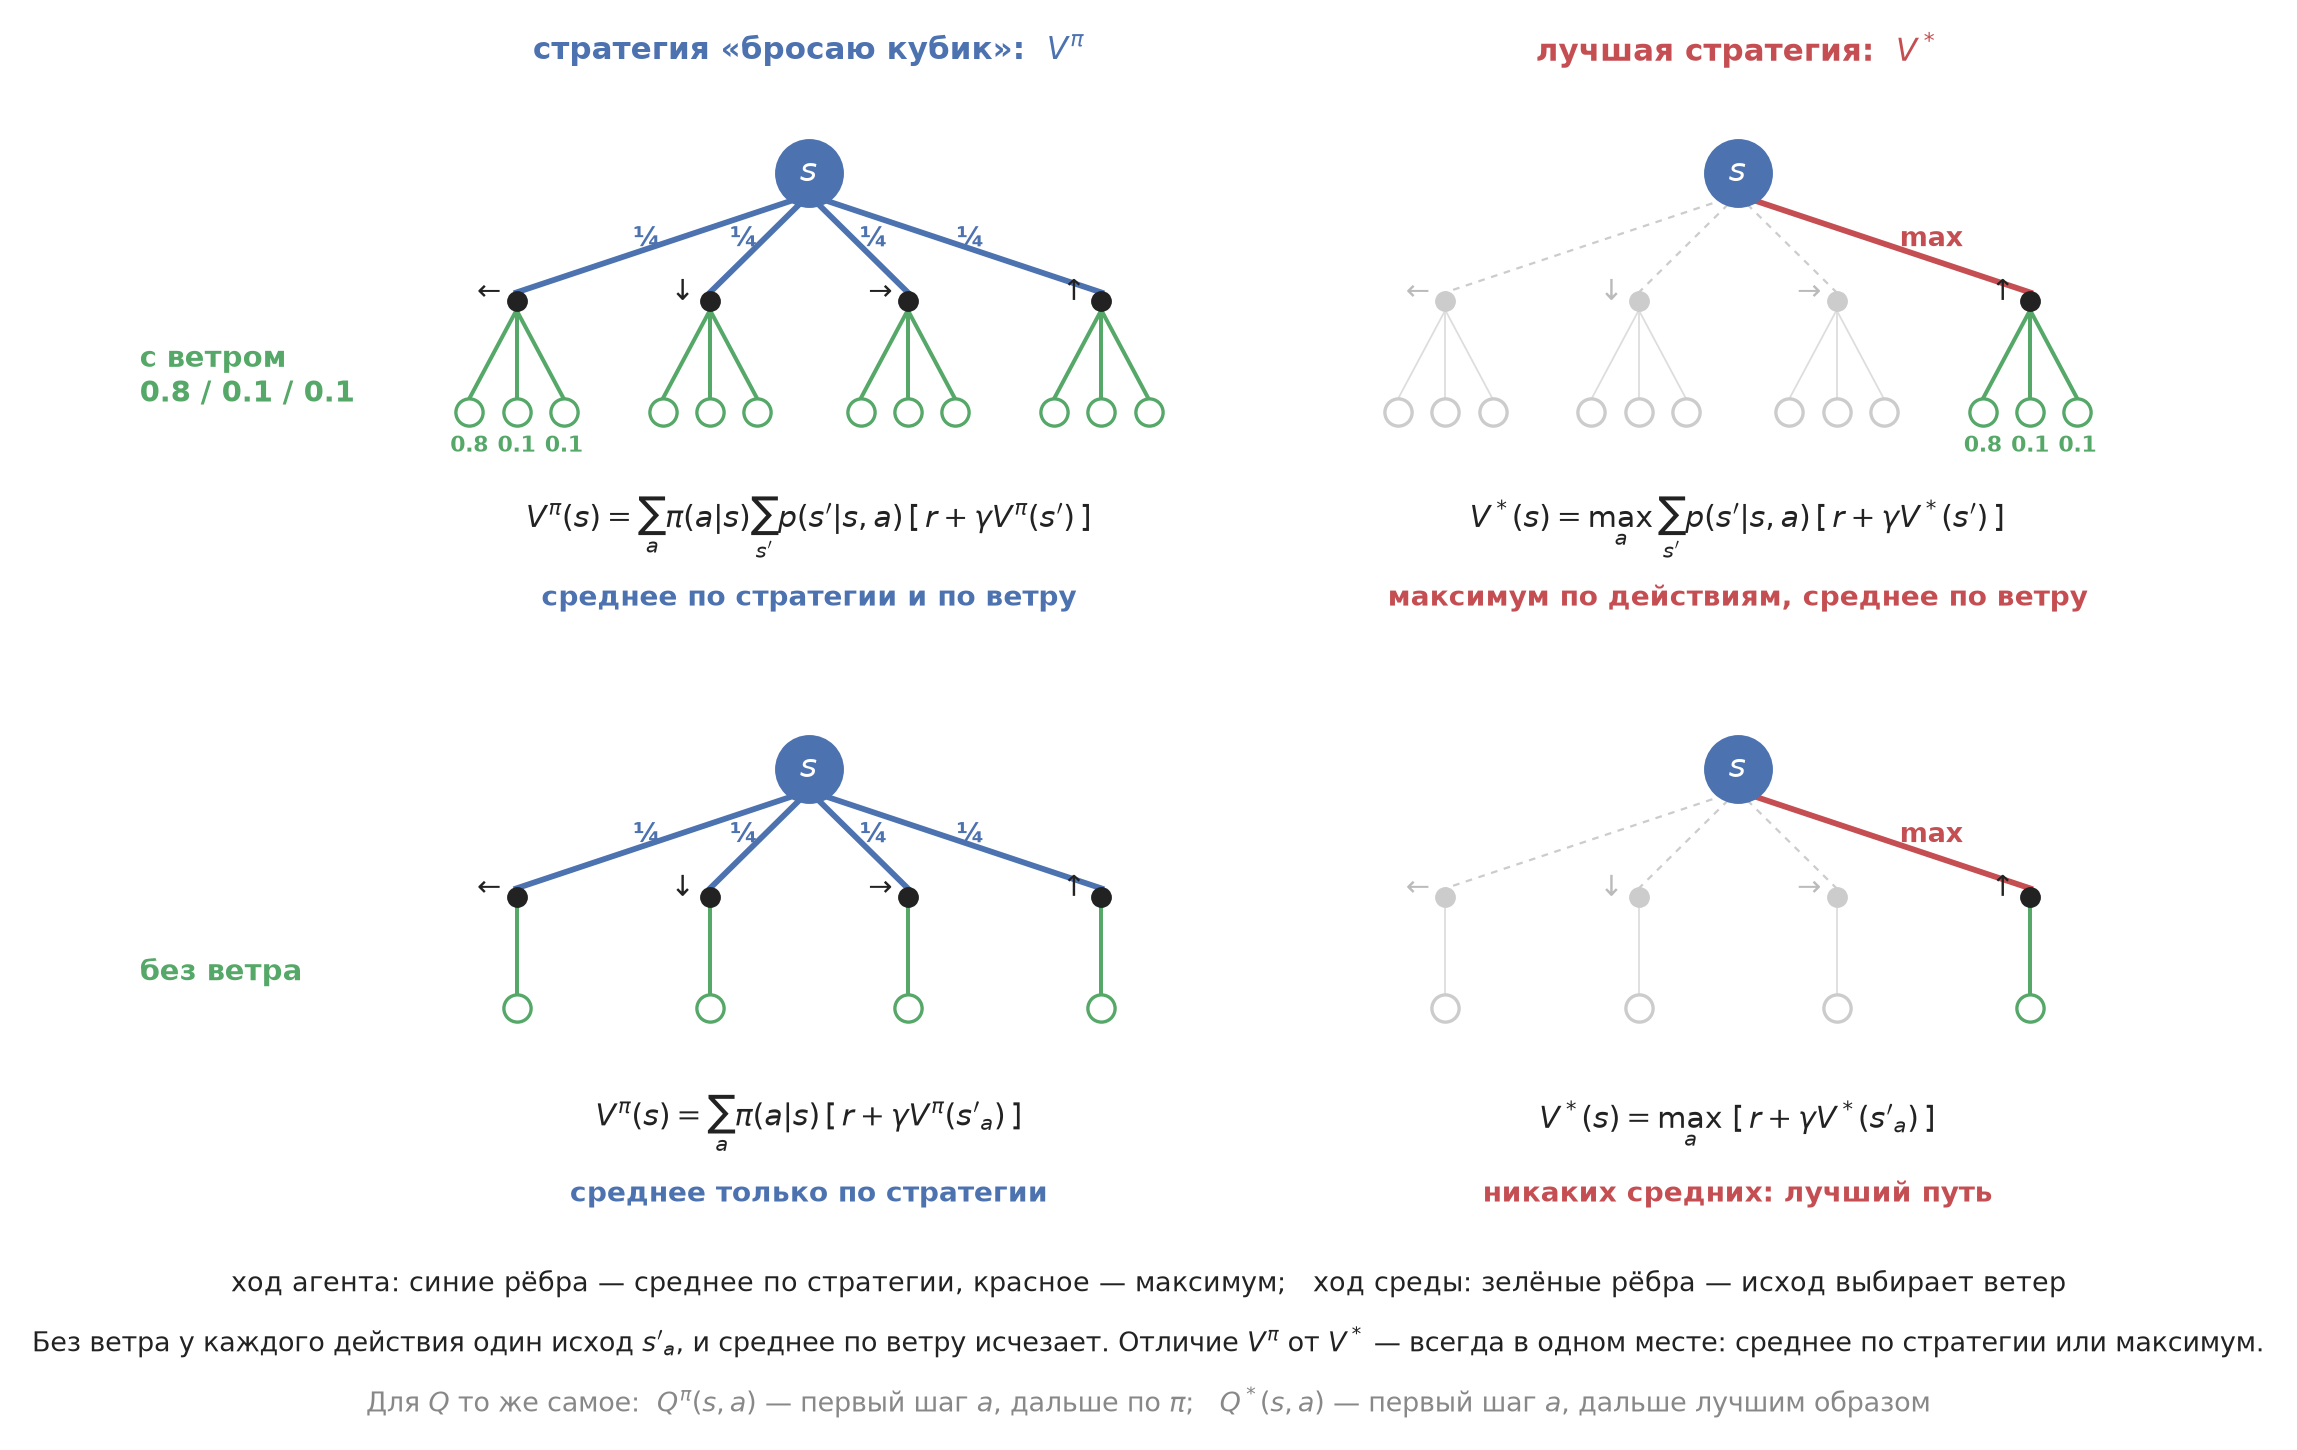

### 1.3 То же для Q

$Q^\pi(s,a)$ — первый шаг $a$ задан, дальше играем по $\pi$. $Q^*(s,a)$ — первый шаг $a$ задан, дальше играем лучшим образом. Те же четыре случая — теперь по четыре числа в клетке, лучшее действие обведено:

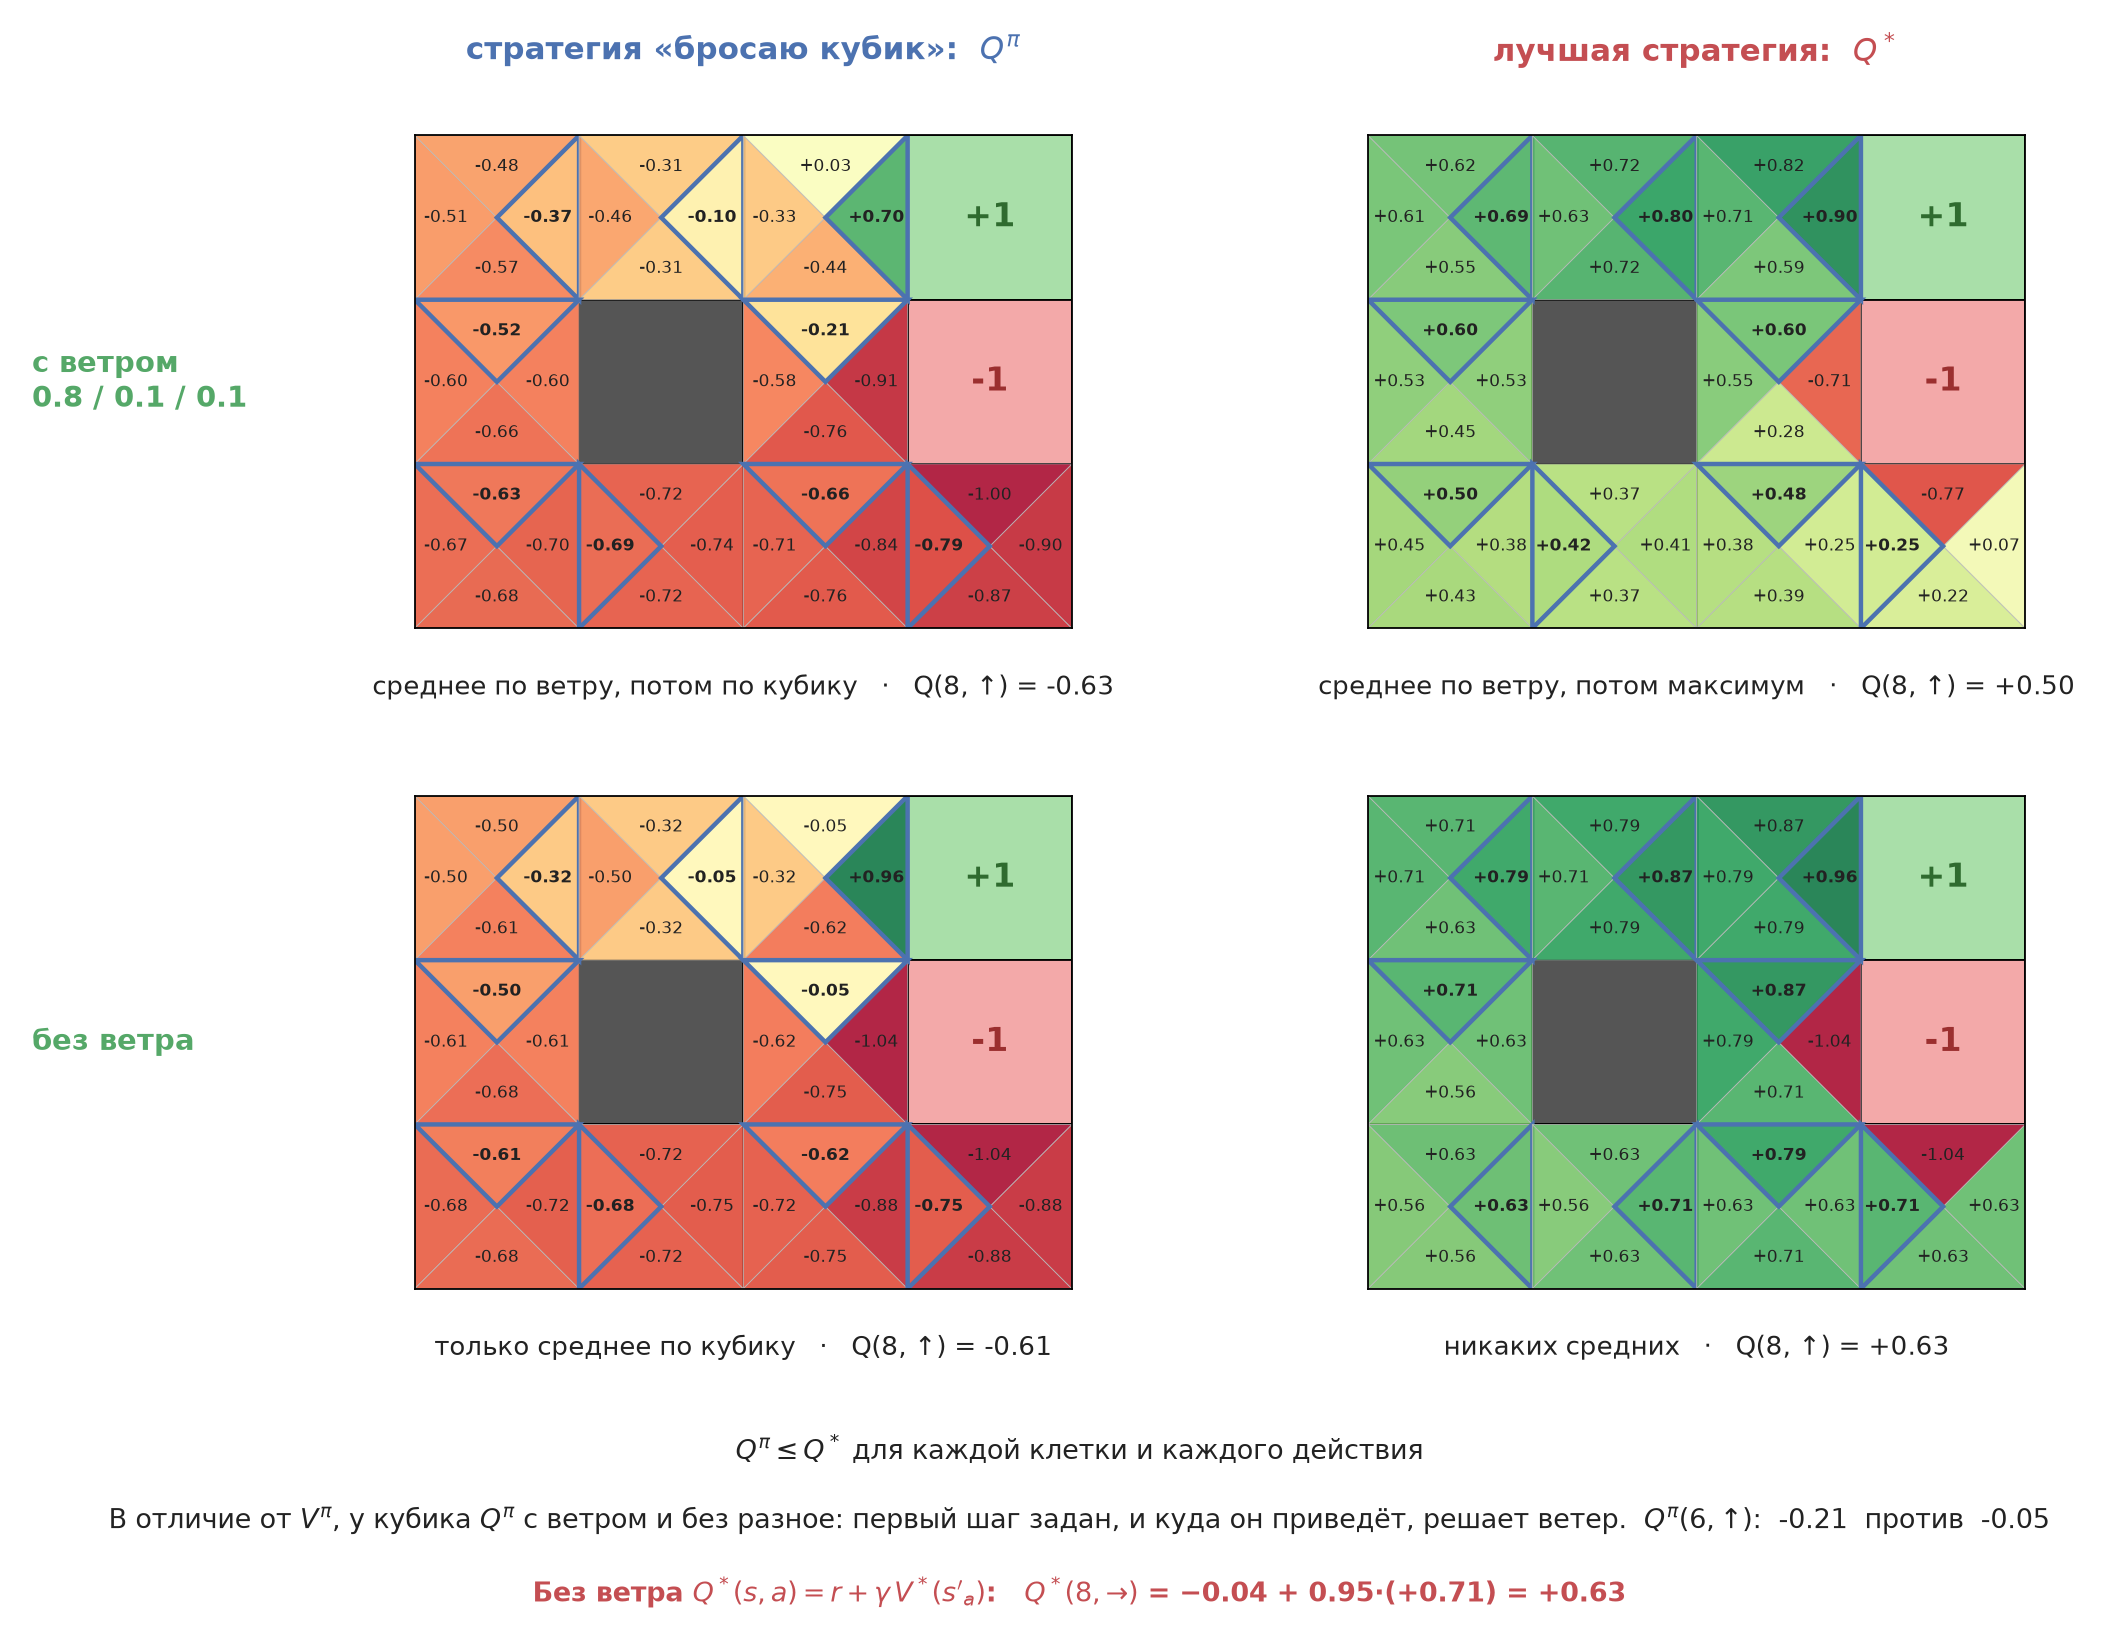

У $Q$ первый ход уже сделан, поэтому дерево начинается не с выбора действия, а с хода среды:

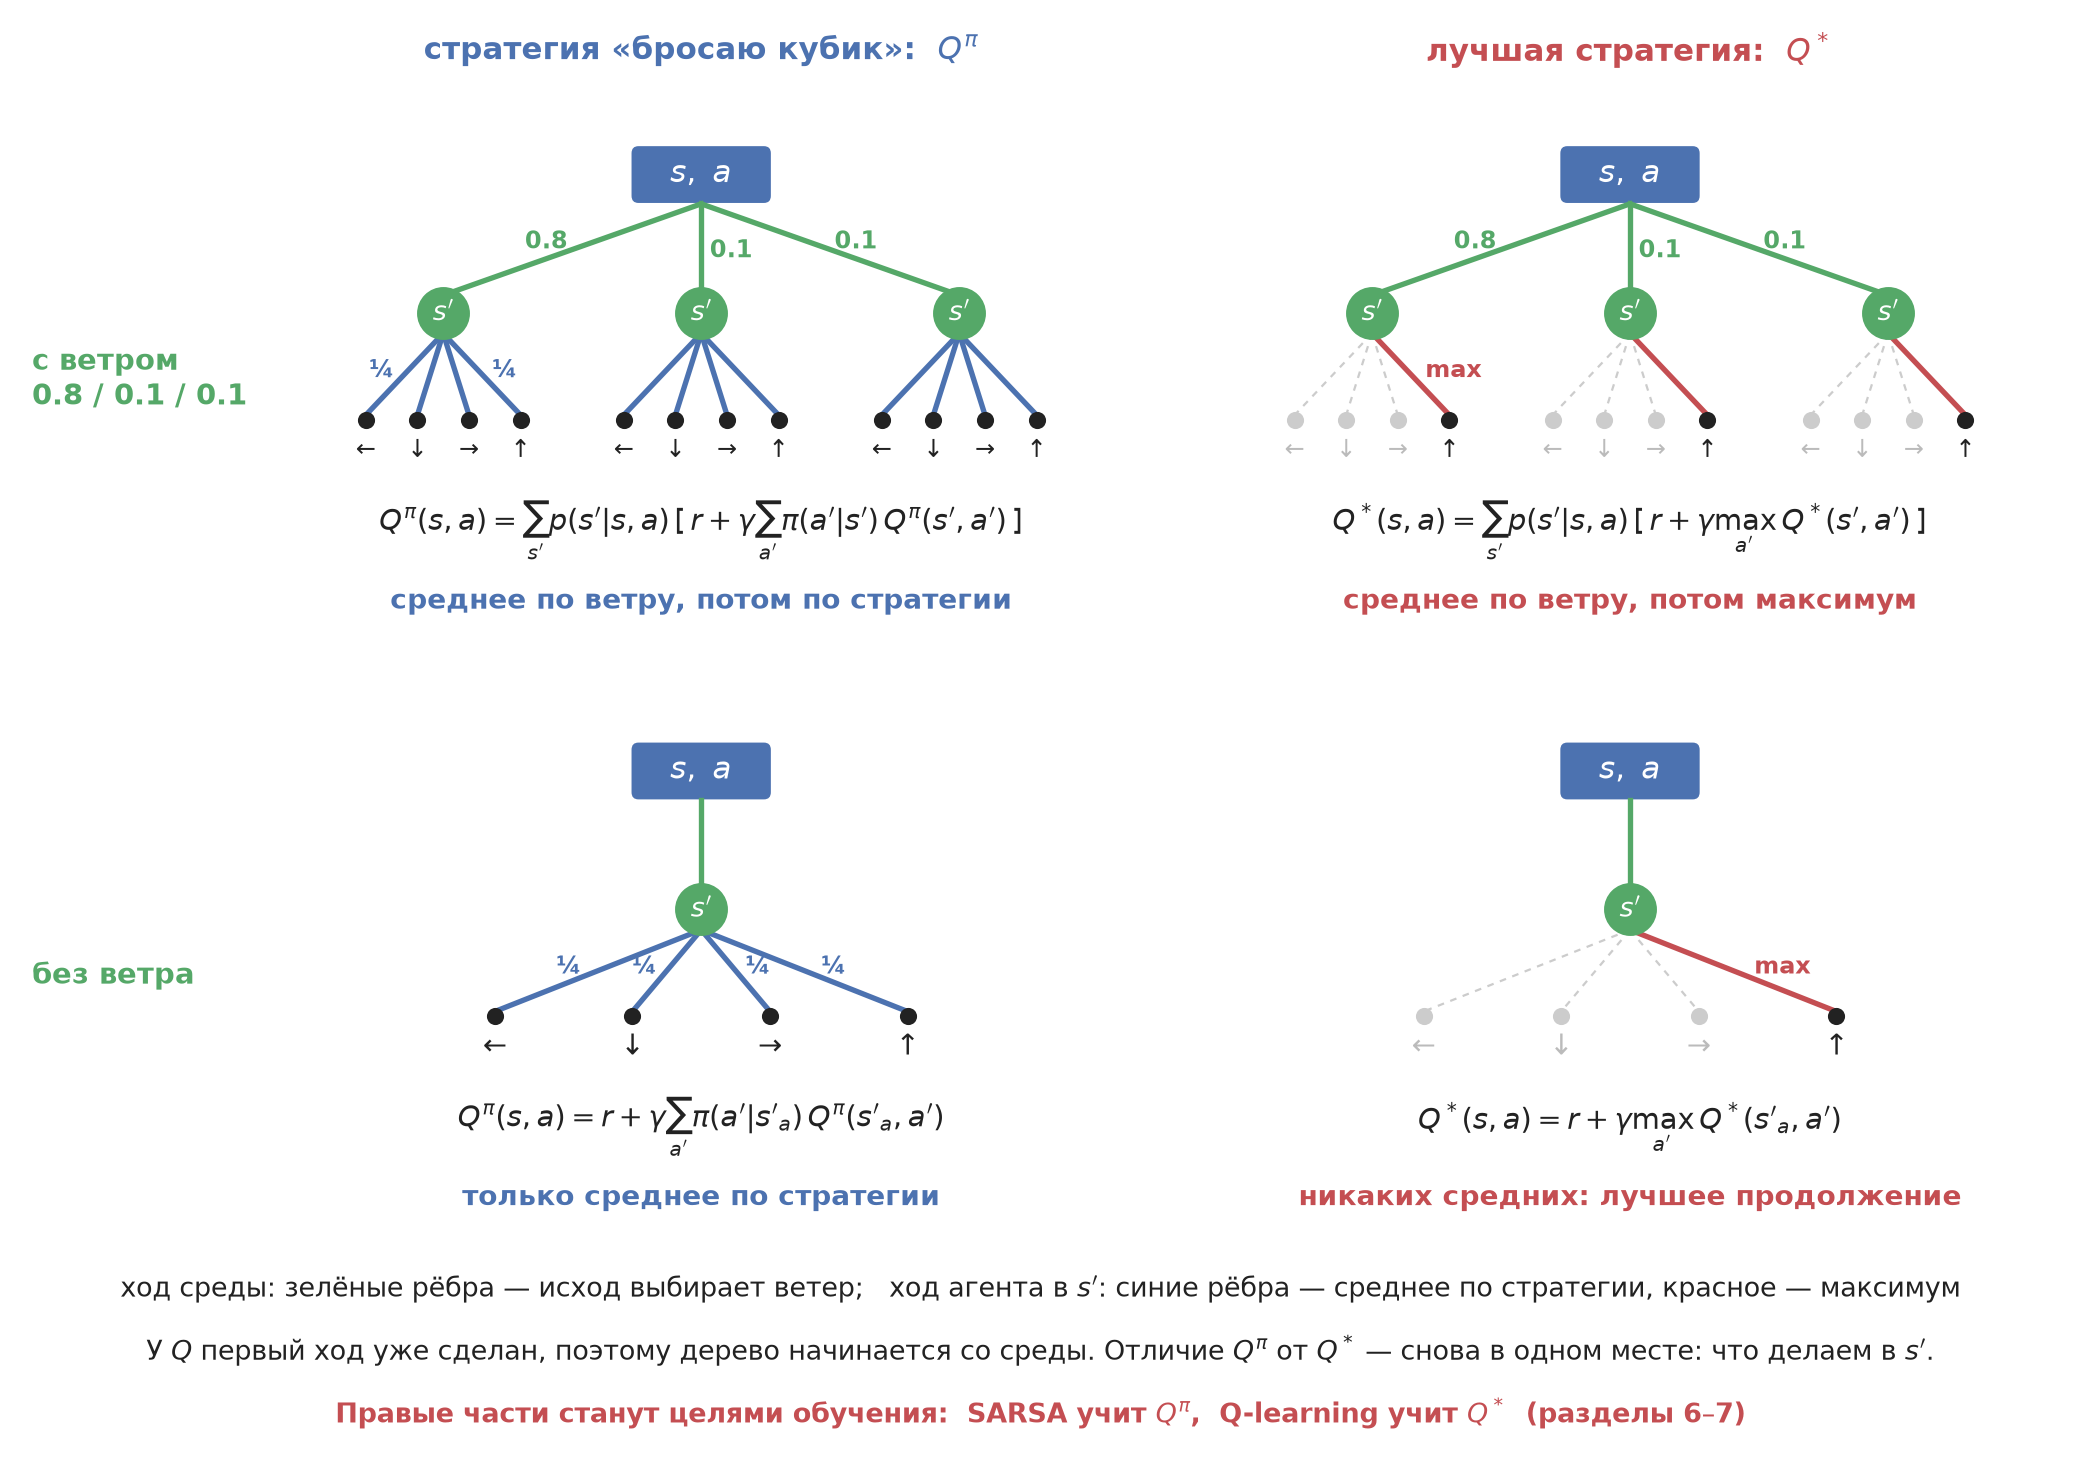

Запомните правые части уравнений из верхнего ряда: в разделах 6–7 из них получатся Q-learning и SARSA.

### 1.4 Как мы её считали

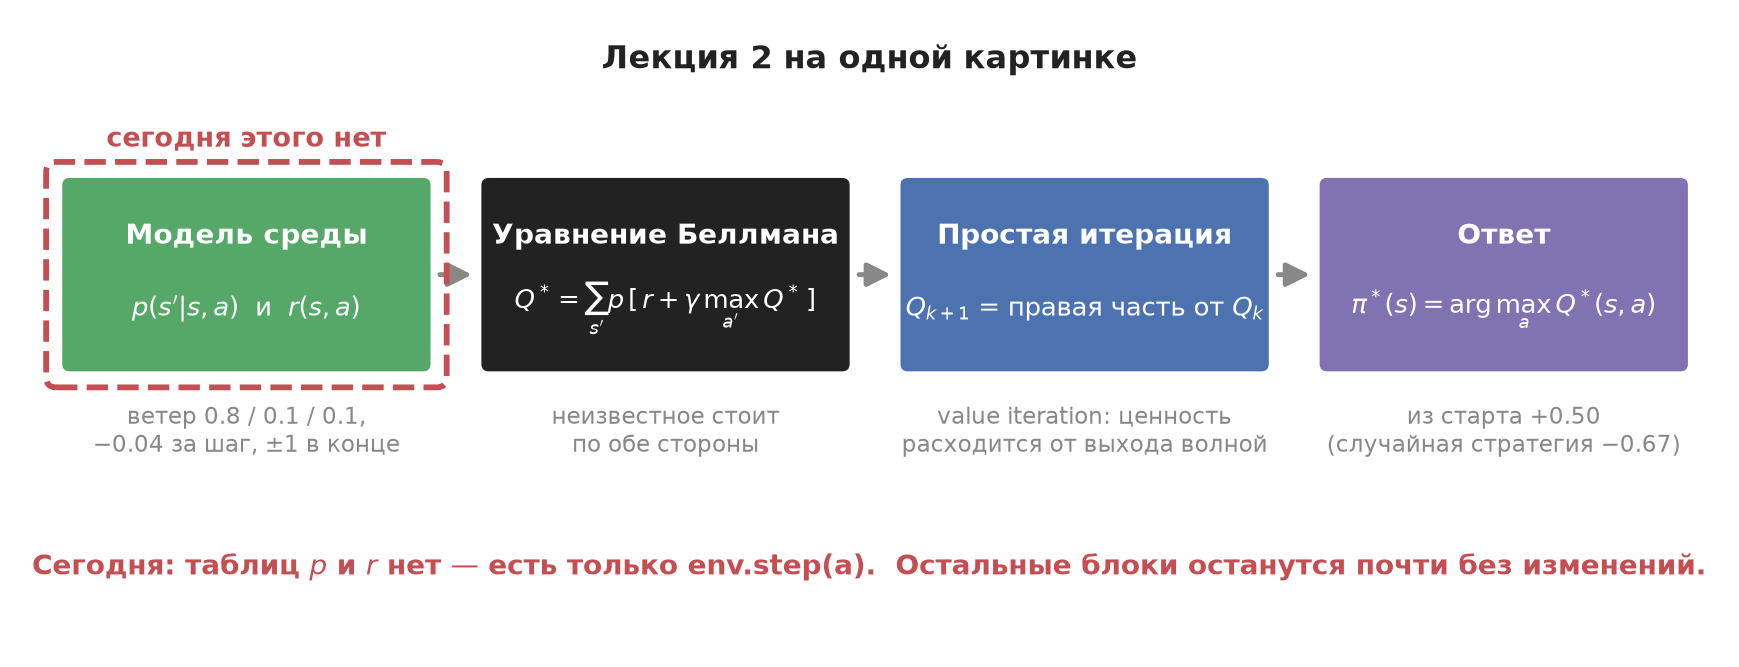

Ответ прошлой лекции — таблица $Q^*$ и жадная стратегия:

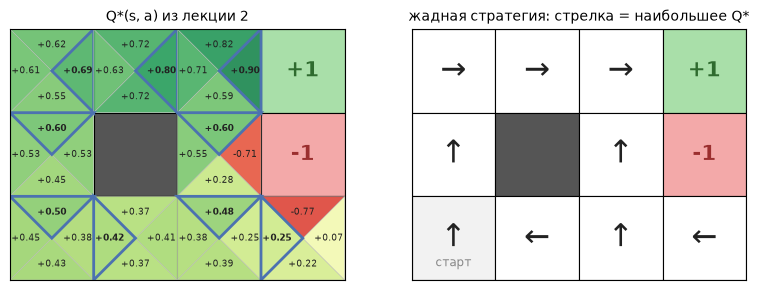

V*(старт) = +0.50


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.6))
plot_q(Q_star, env, ax=axes[0], title="Q*(s, a) из лекции 2")
draw_policy(greedy_policy(Q_star), env, ax=axes[1], title="жадная стратегия: стрелка = наибольшее Q*")
plt.show()
print(f"V*(старт) = {V_star[env.start]:+.2f}")

Это **эталон**: сегодня будем получать те же числа, не заглядывая в `P` и `R`, и сверяться с этими картинками.

### 1.5 Разминка

Ответьте устно, потом откройте ответ.

<details><summary><b>1. Что больше: V*(s) или Q*(s, a)?</b></summary>

$V^*(s) = \max_a Q^*(s,a)$, поэтому $V^*(s) \ge Q^*(s,a)$ для любого действия; равенство — у лучшего. На картинке 1.1: $Q^*(8, →) = +0.38$, а $V^*(8) = +0.50$.
</details>

<details><summary><b>2. Чем уравнение для стратегии π отличается от уравнения оптимальности?</b></summary>

Уравнение для стратегии $\pi$ отвечает на вопрос «сколько соберёт **вот эта** стратегия». В следующей клетке действие выбирает $\pi$, поэтому усредняем по её выбору:

$$
Q^\pi(s,a) = \sum_{s'} p(s' \mid s,a)\,\Big[\,r + \gamma \sum_{a'} \pi(a' \mid s')\, Q^\pi(s',a')\,\Big]
$$

Уравнение оптимальности отвечает на вопрос «сколько можно собрать **в лучшем случае**». В следующей клетке берём лучшее действие:

$$
Q^*(s,a) = \sum_{s'} p(s' \mid s,a)\,\Big[\,r + \gamma \max_{a'} Q^*(s',a')\,\Big]
$$

Отличие одно: среднее $\sum_{a'} \pi(a' \mid s')$ против $\max_{a'}$. Усреднение по ветру $p$, награда $r$ и дисконт $\gamma$ у обоих уравнений общие. Из этого отличия следуют три вещи:

* **$V^\pi \le V^*$ в каждой клетке**: среднее не бывает больше максимума. На картинках 1.2 это левый столбец против правого.
* **Для жадной по $Q^*$ стратегии уравнения совпадают**: вся её вероятность стоит на лучшем действии, и среднее превращается в максимум.
* **Уравнение для $\pi$ линейно**, его можно решить одной системой (`np.linalg.solve`). **Уравнение оптимальности** из-за максимума нелинейно — его решают итерациями, это value iteration.
</details>

<details><summary><b>3. Что делает одна итерация value iteration?</b></summary>

Подставляет текущее приближение в правую часть: $Q_{k+1}(s,a) = r(s,a) + \gamma \sum_{s'} p(s' \mid s,a) \max_{a'} Q_k(s',a')$. Знание о награде продвигается ещё на одну клетку.
</details>

<details><summary><b>4. Почему из клетки 9 стрелка ведёт влево, от выхода?</b></summary>

Короткий путь проходит рядом с ямой, и ветер может туда сдуть. Обход стоит пару лишних шагов по −0.04 — это дешевле риска получить −1.
</details>

## 2. Policy iteration: оценил — улучшил — повторил

🔁 Лекция 2, раздел 7: стратегию можно **оценить** — решить для неё уравнение Беллмана, — и **улучшить** — взять жадную по $Q^\pi$. Новое здесь одно: повторять эти два шага, пока стратегия меняется.

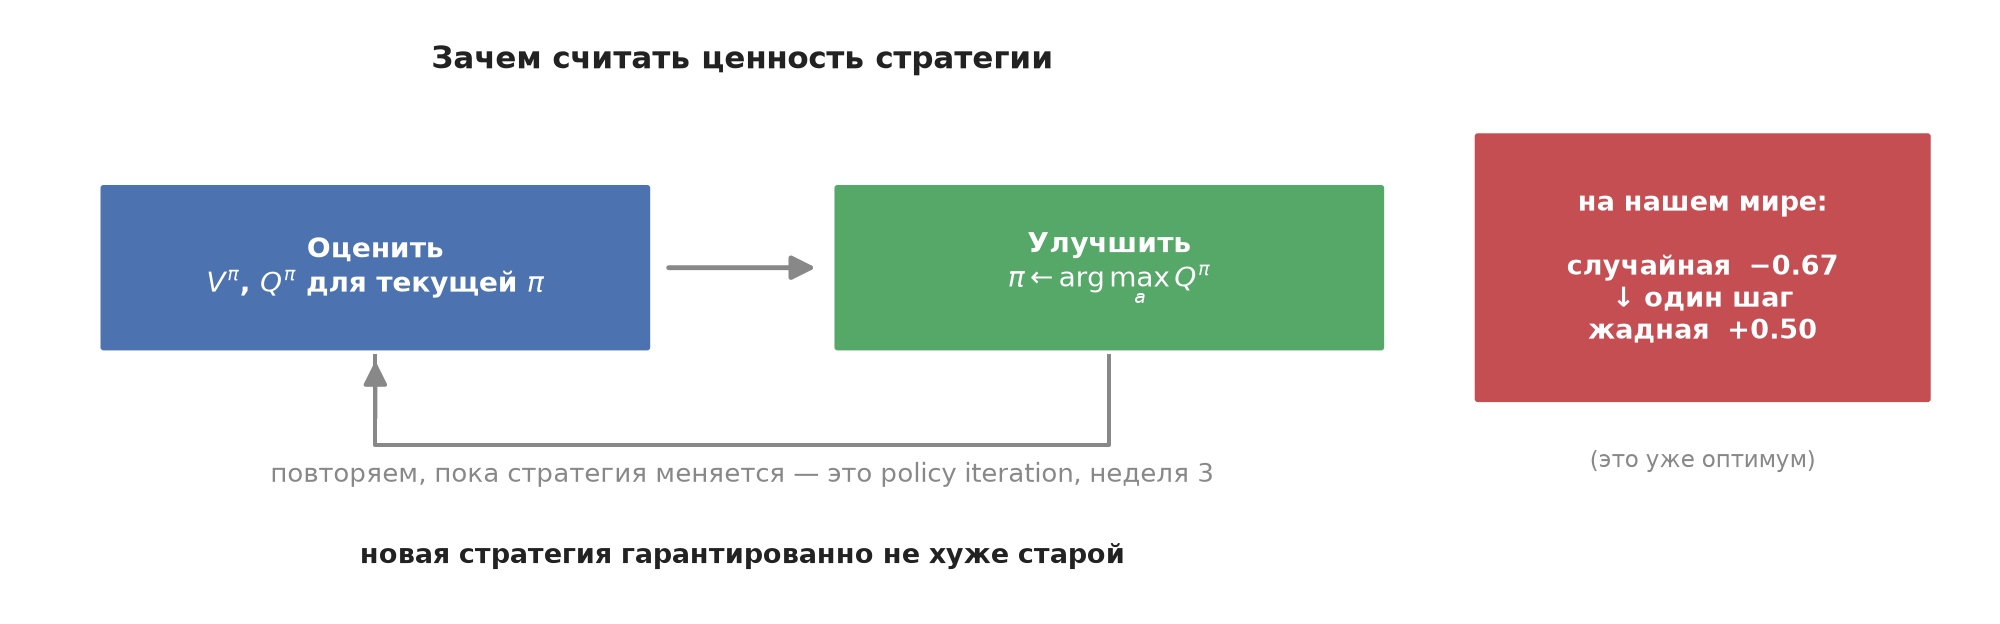

Обе функции у нас уже есть. Вспомним, как устроена первая.

### 2.1 Шаг «оценить»: `evaluate_policy`

Стратегия хранится таблицей `policy[s, a]` $= \pi(a \mid s)$: строка — клетка, в строке вероятности четырёх действий, в сумме 1. У детерминированной стратегии в каждой строке одна единица: у «всегда вверх» — в столбце ↑.

Ищем $Q^\pi$ — решение уравнения Беллмана для стратегии $\pi$ (лекция 2, раздел 4):

$$
Q^\pi(s,a) = r(s,a) + \gamma \sum_{s'} p(s' \mid s,a) \sum_{a'} \pi(a' \mid s')\, Q^\pi(s',a')
$$

Неизвестное стоит по обе стороны, поэтому решаем так же, как value iteration, — простой итерацией. Начинаем с $Q_0 = 0$ и повторяем два шага: ход агента, потом ход среды.

$$
V_k(s) = \sum_a \pi(a \mid s)\, Q_k(s,a),
\qquad
Q_{k+1}(s,a) = r(s,a) + \gamma \sum_{s'} p(s' \mid s,a)\, V_k(s')
$$

Подставьте первую формулу во вторую — получится ровно правая часть уравнения. Каждая формула — одна строка кода:

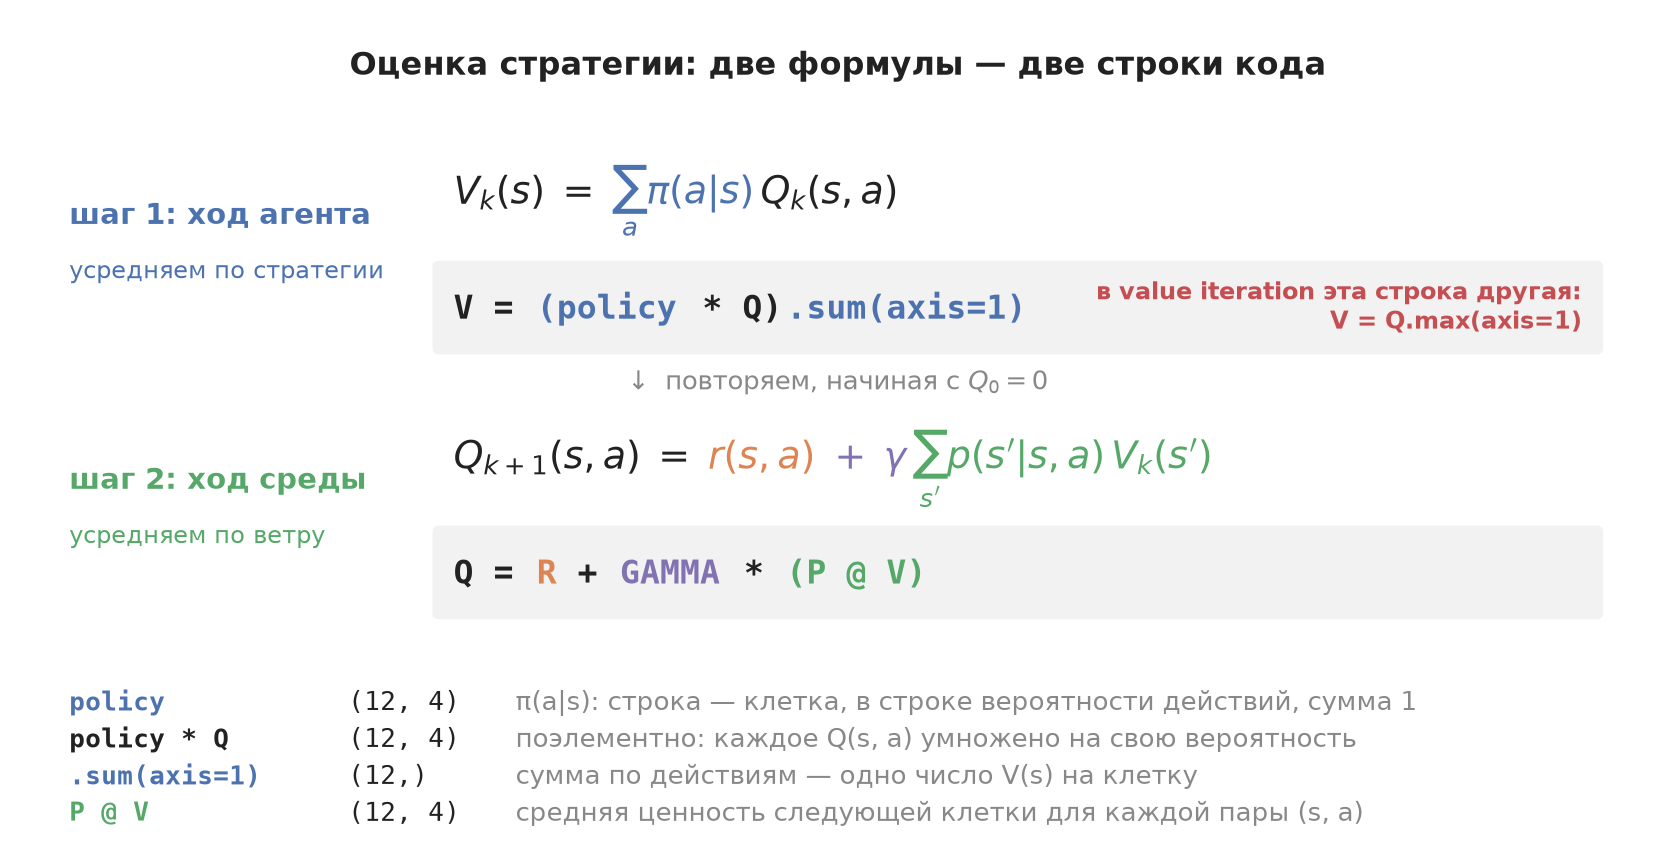

Сколько итераций нужно? Ошибка уменьшается хотя бы в $\gamma$ раз за итерацию (📖 в конце раздела), а $0.95^{500} \approx 7 \cdot 10^{-12}$. Значит, 500 итераций хватает с запасом.

In [4]:
def evaluate_policy(policy, n_iter=500):
    """Ценность заданной стратегии: уравнение Беллмана для π, решённое простой итерацией."""
    Q = np.zeros((env.n_states, env.n_actions))      # Q_0 = 0
    for _ in range(n_iter):
        V = (policy * Q).sum(axis=1)                  # шаг 1: V_k(s) = Σ_a π(a|s) Q_k(s, a)
        Q = R + GAMMA * (P @ V)                       # шаг 2: Q_{k+1}(s, a) = r(s, a) + γ Σ_s' p(s'|s, a) V_k(s')
    return Q

always_up = np.eye(4)[np.full(env.n_states, 3)]       # «всегда вверх»: в каждой строке единица в столбце ↑
print("строка стратегии для клетки 8 (← ↓ → ↑):", always_up[8])

Q_up = evaluate_policy(always_up)
V_up = (always_up * Q_up).sum(axis=1)

# Проверка на одной клетке: старт, действие ↑. Ветер ведёт в клетки 4, 8, 9 с вероятностями 0.8, 0.1, 0.1
rhs = R[8, 3] + GAMMA * (0.8 * V_up[4] + 0.1 * V_up[8] + 0.1 * V_up[9])
print(f"слева:  Q(8, ↑) = {Q_up[8, 3]:+.4f}")
print(f"справа: r + γ·[0.8·V(4) + 0.1·V(8) + 0.1·V(9)] = {R[8, 3]:+.2f} + {GAMMA}·[0.8·({V_up[4]:+.2f}) "
      f"+ 0.1·({V_up[8]:+.2f}) + 0.1·({V_up[9]:+.2f})] = {rhs:+.4f}")

строка стратегии для клетки 8 (← ↓ → ↑): [0. 0. 0. 1.]
слева:  Q(8, ↑) = -0.5066
справа: r + γ·[0.8·V(4) + 0.1·V(8) + 0.1·V(9)] = -0.04 + 0.95·[0.8·(-0.49) + 0.1·(-0.51) + 0.1·(-0.45)] = -0.5066


Левая и правая части совпали: таблица `Q_up` — решение уравнения для «всегда вверх». Из старта эта стратегия собирает −0.51: агент упирается в верхний край и платит за шаги, пока ветер не снесёт его вбок — обычно к выходу, а иногда и в яму.

Заметьте: ни одного вызова `env.step` — всё, что нужно, лежит в таблицах `P` и `R`. Это и есть ограничение DP; что делать без таблиц — раздел 3.

### 2.2 Шаг «улучшить» и цикл

`greedy_policy(Q)` — шаг улучшения из лекции 2, раздел 7.1. В каждой клетке ставим единицу на действие с наибольшим $Q^\pi$:

$$
\pi_{\text{new}}(s) = \arg\max_a Q^\pi(s,a)
$$

Повторяем «оценить → улучшить», пока стратегия меняется.

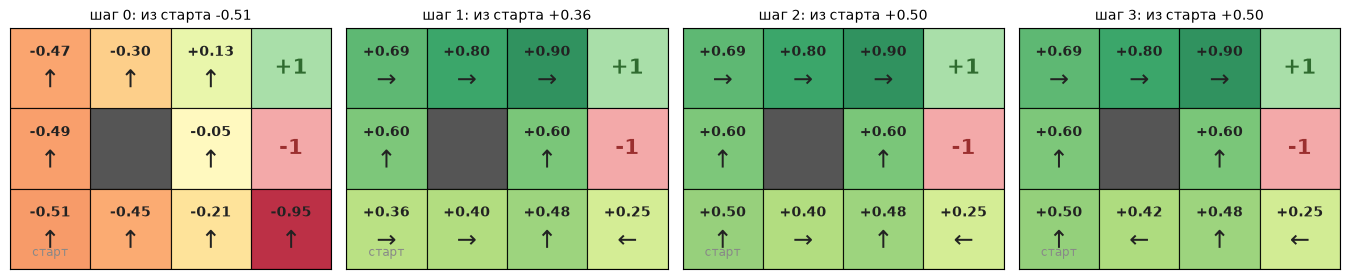

совпало с оптимальной стратегией лекции 2: True


In [5]:
policy = always_up
history = []
for i in range(10):
    Q_pi = evaluate_policy(policy)                    # шаг «оценить»
    history.append((policy, (policy * Q_pi).sum(axis=1)))
    new_policy = greedy_policy(Q_pi)                  # шаг «улучшить»
    if np.array_equal(new_policy, policy):            # стратегия не изменилась — это оптимум
        break
    policy = new_policy

fig, axes = plt.subplots(1, len(history), figsize=(3.4 * len(history), 3.2))
for k, (ax, (pol, V)) in enumerate(zip(axes, history)):
    draw_policy(pol, env, ax=ax, values=V, title=f"шаг {k}: из старта {V[env.start]:+.2f}")
plt.tight_layout(); plt.show()
print("совпало с оптимальной стратегией лекции 2:", np.array_equal(policy.argmax(1)[CELLS], Q_star.argmax(1)[CELLS]))

Три улучшения — и оптимум: −0.51 → +0.36 → +0.50 → +0.50. Третье улучшение поменяло только клетку 9 (→ на ←), из старта этого не видно; на четвёртом шаге стратегия уже не меняется. Каждый шаг не хуже предыдущего (лекция 2, раздел 7.1), а различных стратегий конечное число, поэтому цикл обязательно остановится.

**Value iteration или policy iteration?** Ответ один и тот же. VI делает много дешёвых итераций (одна строка numpy), PI — мало дорогих (каждая — целая оценка стратегии).

📖 **Почему итерации вообще сходятся.** За одну итерацию VI расстояние до ответа уменьшается минимум в $\gamma$ раз: $\max |Q_{k+1} - Q^*| \le \gamma \max |Q_k - Q^*|$. Доказательство в одну строку: разность правых частей равна $\gamma \sum_{s'} p\,(\max Q_k - \max Q^*)$, разность максимумов не больше максимальной разности, а веса $p$ в сумме дают 1. Проверим числами.

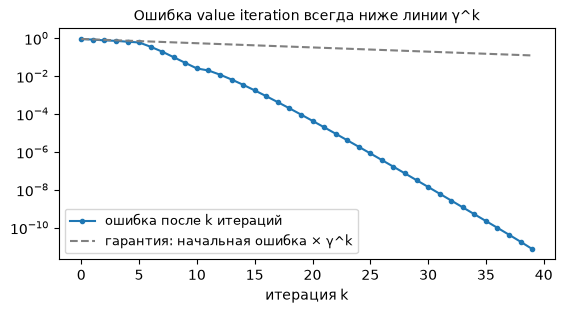

In [6]:
Q, errors = np.zeros_like(Q_star), []
for k in range(40):
    errors.append(np.abs(Q - Q_star).max())
    Q = R + GAMMA * (P @ Q.max(axis=1))               # одна итерация value iteration

plt.figure(figsize=(6.4, 3))
plt.semilogy(errors, "o-", ms=3, label="ошибка после k итераций")
plt.semilogy(errors[0] * GAMMA ** np.arange(40), "--", color="grey", label="гарантия: начальная ошибка × γ^k")
plt.xlabel("итерация k"); plt.legend(fontsize=9)
plt.title("Ошибка value iteration всегда ниже линии γ^k", fontsize=10); plt.show()

**Одной строкой:** DP-методы находят оптимум точно, но каждому нужны таблицы `P` и `R`.

## 3. Модели нет: что остаётся

🔁 Лекция 2 закончилась ограничением: всё считалось по модели среды. Но, катаясь на велосипеде, вы не знаете, с какой вероятностью окажетесь через секунду в каждом положении. Остаётся одно — пробовать.

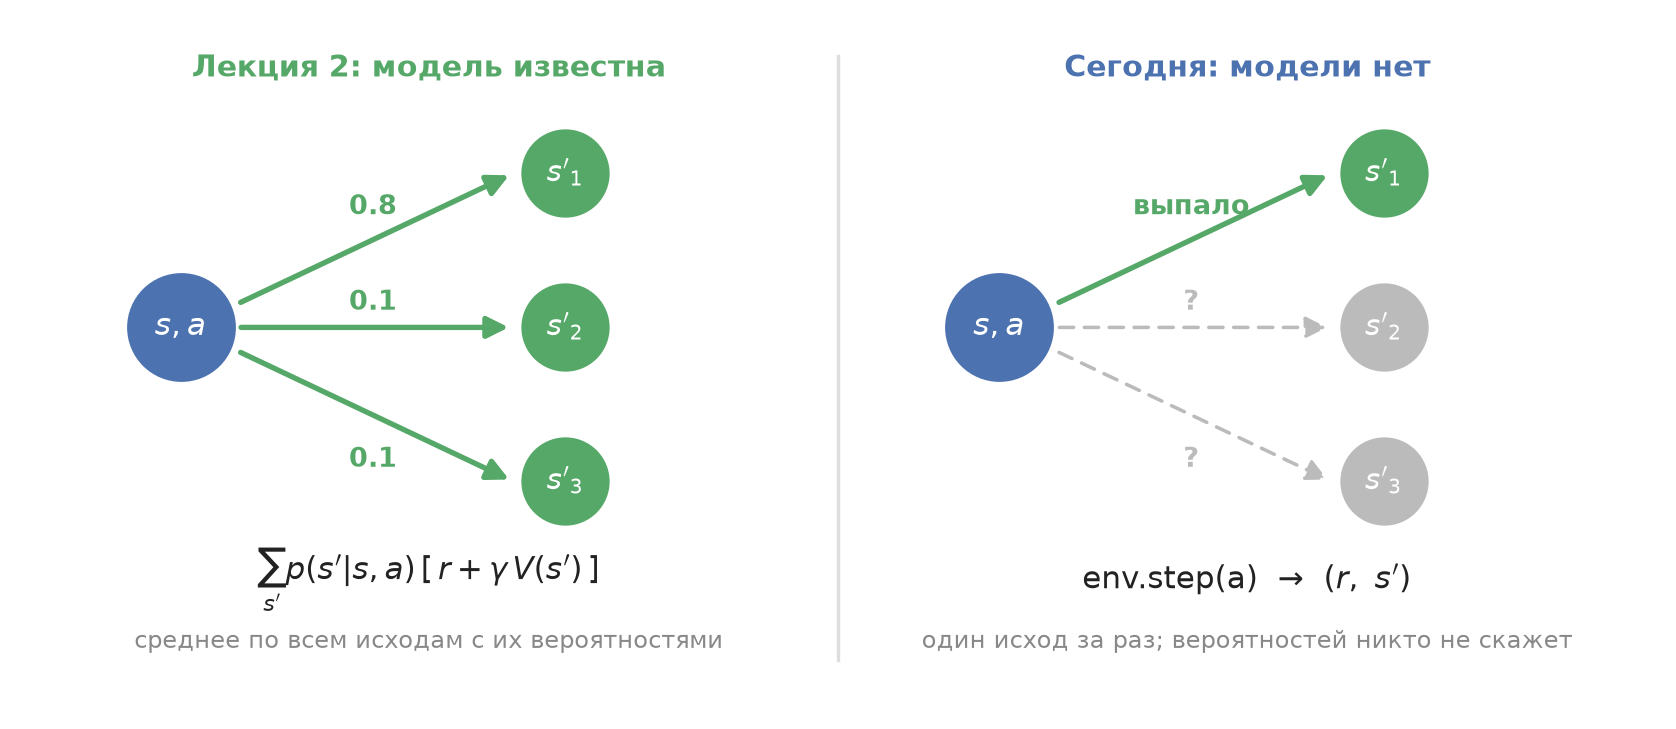

Попросим среду 1000 раз сделать «вверх» из старта.

In [7]:
outcomes = []
for i in range(1000):
    env.reset(seed=i)
    s_next, r, *_ = env.step(3)                       # из старта (клетка 8) просим «вверх»
    outcomes.append(s_next)

print("первые 20 исходов:", outcomes[:20])
for s_next in sorted(set(outcomes)):
    print(f"  клетка {s_next}: частота {outcomes.count(s_next) / len(outcomes):.3f},   "
          f"вероятность из модели {P[8, 3, s_next]:.1f}")

первые 20 исходов: [4, 4, 4, 4, 9, 8, 4, 4, 4, 8, 9, 4, 4, 8, 8, 4, 4, 8, 4, 4]
  клетка 4: частота 0.796,   вероятность из модели 0.8
  клетка 8: частота 0.091,   вероятность из модели 0.1
  клетка 9: частота 0.113,   вероятность из модели 0.1


Вероятностей среда не сообщает, но частоты к ним сходятся — это закон больших чисел, на котором стоял Монте-Карло в лекции 1. Значит, любую сумму вида $\sum_{s'} p(s' \mid s,a)\,[\,\dots]$ можно заменить **средним по попыткам**. Осталось научиться усреднять так, чтобы не хранить все попытки.

**Одной строкой:** нет модели — усредняем по попыткам.

## 4. Среднее на ходу

Пример без всякого RL. Каждое утро вы едете в университет и хотите знать, сколько обычно занимает дорога. Пересчитывать среднее по всем дням не нужно — достаточно поправлять одно число:

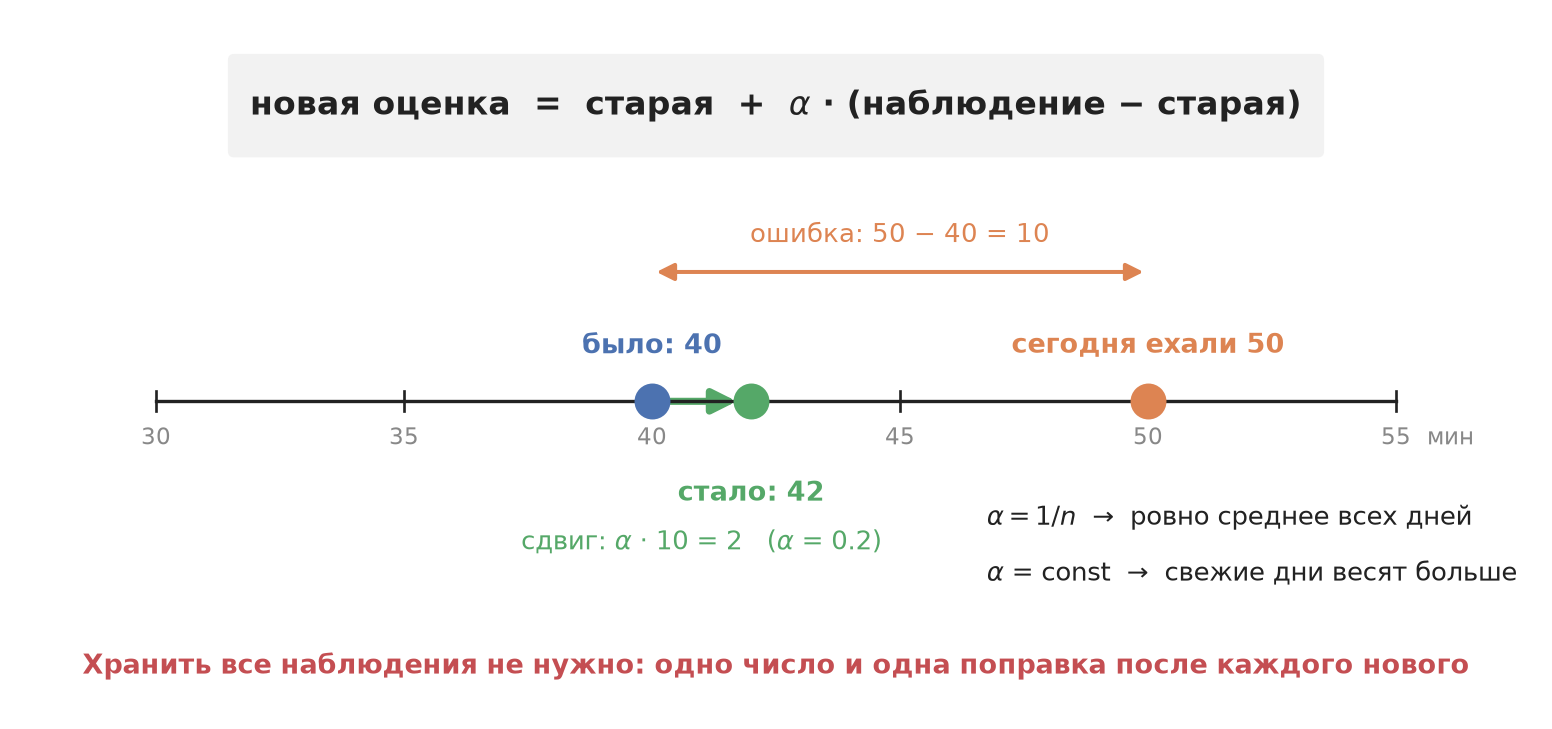

$$
m \leftarrow m + \alpha\,(x - m)
$$

При $\alpha = 1/n$, где $n$ — номер дня, это ровно обычное среднее. При постоянном $\alpha$ свежие дни весят больше. Проверим на двух месяцах поездок.

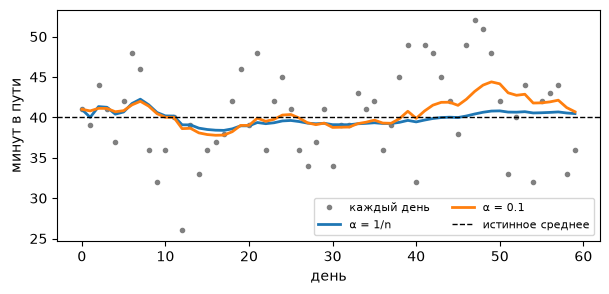

α = 1/n после 60 дней: 40.467;   np.mean по всем дням: 40.467


In [8]:
rng = np.random.default_rng(0)
days = rng.normal(40, 6, size=60).round()             # минуты в пути: в среднем 40, разброс около 6

m_exact, m_const = 0.0, days[0]
hist_exact, hist_const = [], []
for n, x in enumerate(days, start=1):
    m_exact += (1 / n) * (x - m_exact)                # α = 1/n
    m_const += 0.1 * (x - m_const)                    # α = 0.1
    hist_exact.append(m_exact); hist_const.append(m_const)

plt.figure(figsize=(7, 3))
plt.plot(days, ".", color="grey", label="каждый день")
plt.plot(hist_exact, lw=2, label="α = 1/n")
plt.plot(hist_const, lw=2, label="α = 0.1")
plt.axhline(40, color="k", ls="--", lw=1, label="истинное среднее")
plt.xlabel("день"); plt.ylabel("минут в пути"); plt.legend(fontsize=8, ncol=2); plt.show()
print(f"α = 1/n после 60 дней: {m_exact:.3f};   np.mean по всем дням: {days.mean():.3f}")

Оценка с $\alpha = 1/n$ совпала с `np.mean`, хотя все дни мы ни разу не хранили. С постоянным $\alpha$ оценка дрожит, зато успевает за переменами: откроют новую станцию метро — она заметит это за пару недель. В RL «цель» постоянно меняется, потому что меняются оценки самого агента, поэтому обычно берут постоянное $\alpha$.

> **Шаблон на всю лекцию:** новая оценка = старая + $\alpha$ · (цель − старая). Все сегодняшние алгоритмы — этот шаблон; меняется только «цель».

**Одной строкой:** среднее считается на ходу, одной поправкой.

## 5. Монте-Карло и TD: учимся по дороге

🔁 Лекция 1, раздел 11: ценность клетки по Монте-Карло — средний return, набранный после попадания в клетку. По шаблону раздела 4:

$$
V(s) \leftarrow V(s) + \alpha\,\big(G_t - V(s)\big)
$$

Цель — return $G_t$, фактически набранный до конца эпизода. Неудобство одно: $G_t$ известен только **после конца эпизода**.

🔁 Лекция 2, раздел 6: $G_t = r_t + \gamma\, G_{t+1}$, а «хвост» $G_{t+1}$ в среднем равен $V(s_{t+1})$. Значит, вместо ожидания конца можно взять оценку следующей клетки:

$$
V(s) \leftarrow V(s) + \alpha\,\big(\underbrace{r + \gamma V(s')}_{\text{цель TD}} - V(s)\big)
$$

Это **TD-обучение** (temporal difference, «разность во времени»). Скобка $\delta = r + \gamma V(s') - V(s)$ — **TD-ошибка**: насколько следующий прогноз разошёлся с нынешним.

Пример — та же дорога в университет. На каждой остановке вы заново прикидываете, сколько займёт вся дорога:

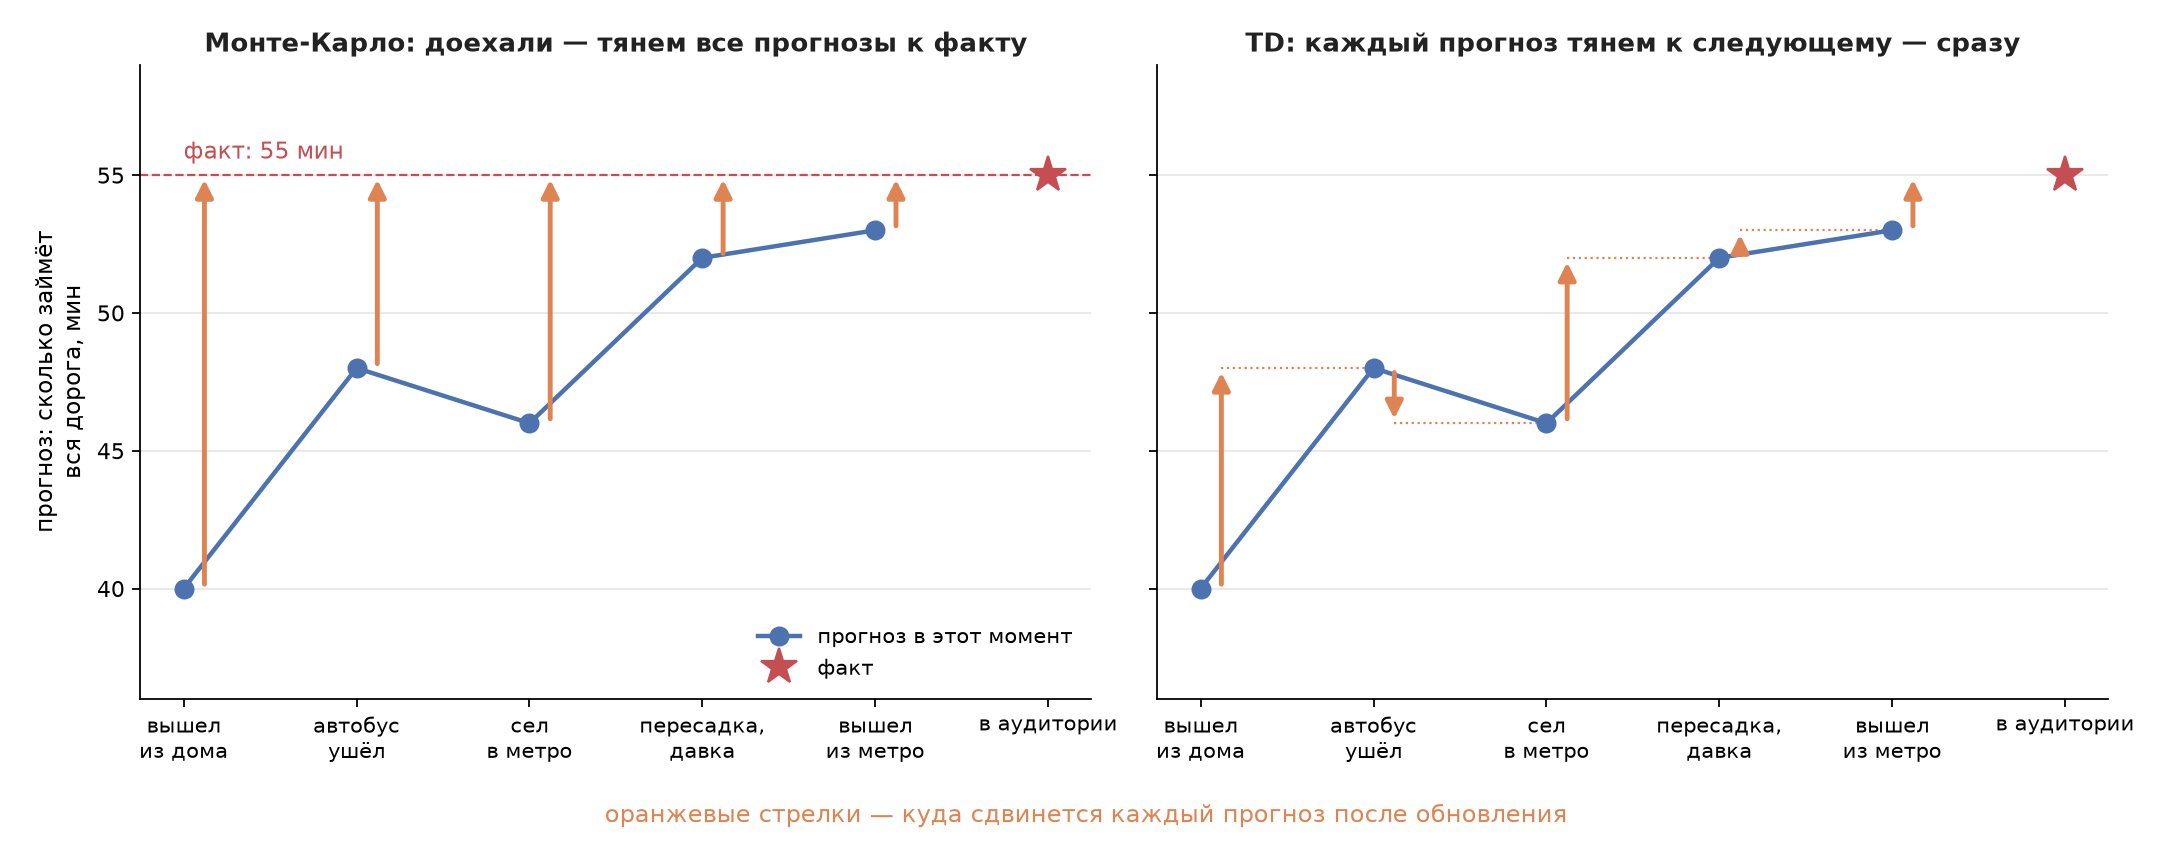

Монте-Карло исправляет прогнозы, только доехав. TD исправляет прогноз «40 минут», как только автобус ушёл перед носом: следующий прогноз уже 48, и ждать конца пути не нужно.

In [9]:
uniform = uniform_policy(env)                                  # стратегия «бросаю кубик»
V_true = (uniform * evaluate_policy(uniform)).sum(axis=1)      # точный ответ (раздел 2) — для проверки

def mc_update(V, states, rewards, alpha):
    """Монте-Карло: после эпизода тянем V(s) к фактическому return G."""
    G = 0.0
    for t in reversed(range(len(rewards))):                    # return удобно считать с конца эпизода
        G = rewards[t] + GAMMA * G
        V[states[t]] += alpha * (G - V[states[t]])

def td_update(V, states, rewards, alpha):
    """TD(0): после каждого шага тянем V(s) к r + γ V(s')."""
    for t in range(len(rewards)):                              # то же, что обновлять прямо во время эпизода
        s, s_next = states[t], states[t + 1]
        future = 0.0 if env.is_terminal(s_next) else V[s_next] # у терминальной клетки будущего нет
        V[s] += alpha * (rewards[t] + GAMMA * future - V[s])

Заметьте: `mc_update` и `td_update` стратегию не знают — они видят только переходы. Чью ценность они выучат, решают данные: какой стратегией сыграны эпизоды. Для демо берём «кубик» — он обходит все клетки, и карту можно сверить с точным ответом целиком.

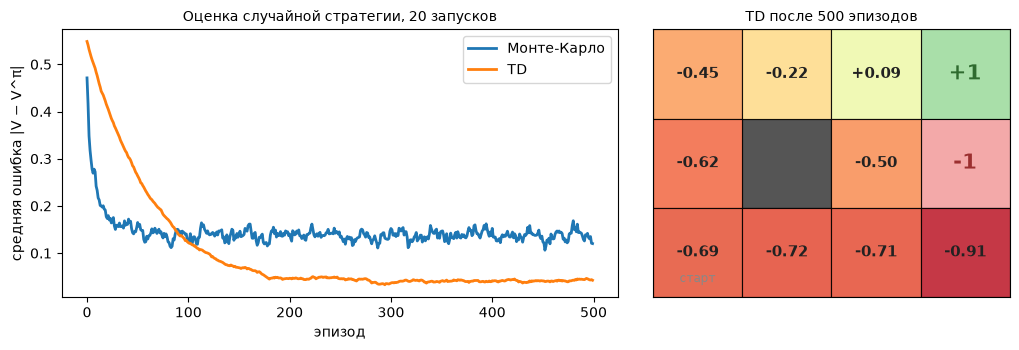

 Монте-Карло: ошибка после 20 эпизодов 0.177, после 500 — 0.120
          TD: ошибка после 20 эпизодов 0.416, после 500 — 0.043


In [10]:
def run_evaluation(update, policy=uniform, n_episodes=500, alpha=0.05, seed=0):
    rng = np.random.default_rng(seed)
    V, errors = np.zeros(env.n_states), []
    for _ in range(n_episodes):
        states, actions, rewards = run_episode(env, policy, rng)     # эпизоды играет заданная стратегия
        update(V, states, rewards, alpha)
        errors.append(np.abs(V[CELLS] - V_true[CELLS]).mean())
    return V, errors

curves = {name: np.array([run_evaluation(update, seed=seed)[1] for seed in range(20)])
          for name, update in [("Монте-Карло", mc_update), ("TD", td_update)]}
V_td, _ = run_evaluation(td_update)

fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.6), gridspec_kw={"width_ratios": [1.4, 1]})
for name, c in curves.items():
    axes[0].plot(c.mean(axis=0), lw=2, label=name)
axes[0].set_xlabel("эпизод"); axes[0].set_ylabel("средняя ошибка |V − V^π|")
axes[0].set_title("Оценка случайной стратегии, 20 запусков", fontsize=10); axes[0].legend()
plot_values(V_td, env, ax=axes[1], title="TD после 500 эпизодов")
plt.tight_layout(); plt.show()
for name, c in curves.items():
    print(f"{name:>12}: ошибка после 20 эпизодов {c[:, 19].mean():.3f}, после 500 — {c[:, -1].mean():.3f}")

Оба метода идут к ответу из раздела 2, ни разу не открыв `P`. Монте-Карло быстрее стартует: его цель — честный return, хоть и шумный; с убывающим $\alpha = 1/n$ он пришёл бы точно, но медленно, а при постоянном $\alpha$ так и дрожит с ошибкой около 0.12. TD поначалу опирается на собственные нулевые оценки и раскачивается дольше, зато его цель почти не шумит, и к концу он точнее.

| | Монте-Карло | TD |
|---|---|---|
| цель | $G_t$ — весь хвост эпизода | $r + \gamma V(s')$ — один шаг |
| ждать конца эпизода | да | нет, учится после каждого шага |
| смещение | нет: $G_t$ честный | есть: опирается на свою же оценку |
| шум | большой: в $G_t$ вся случайность хвоста | маленький: случайность одного шага |

Всё увиденное — на одной картинке: что нужно для одного обновления.

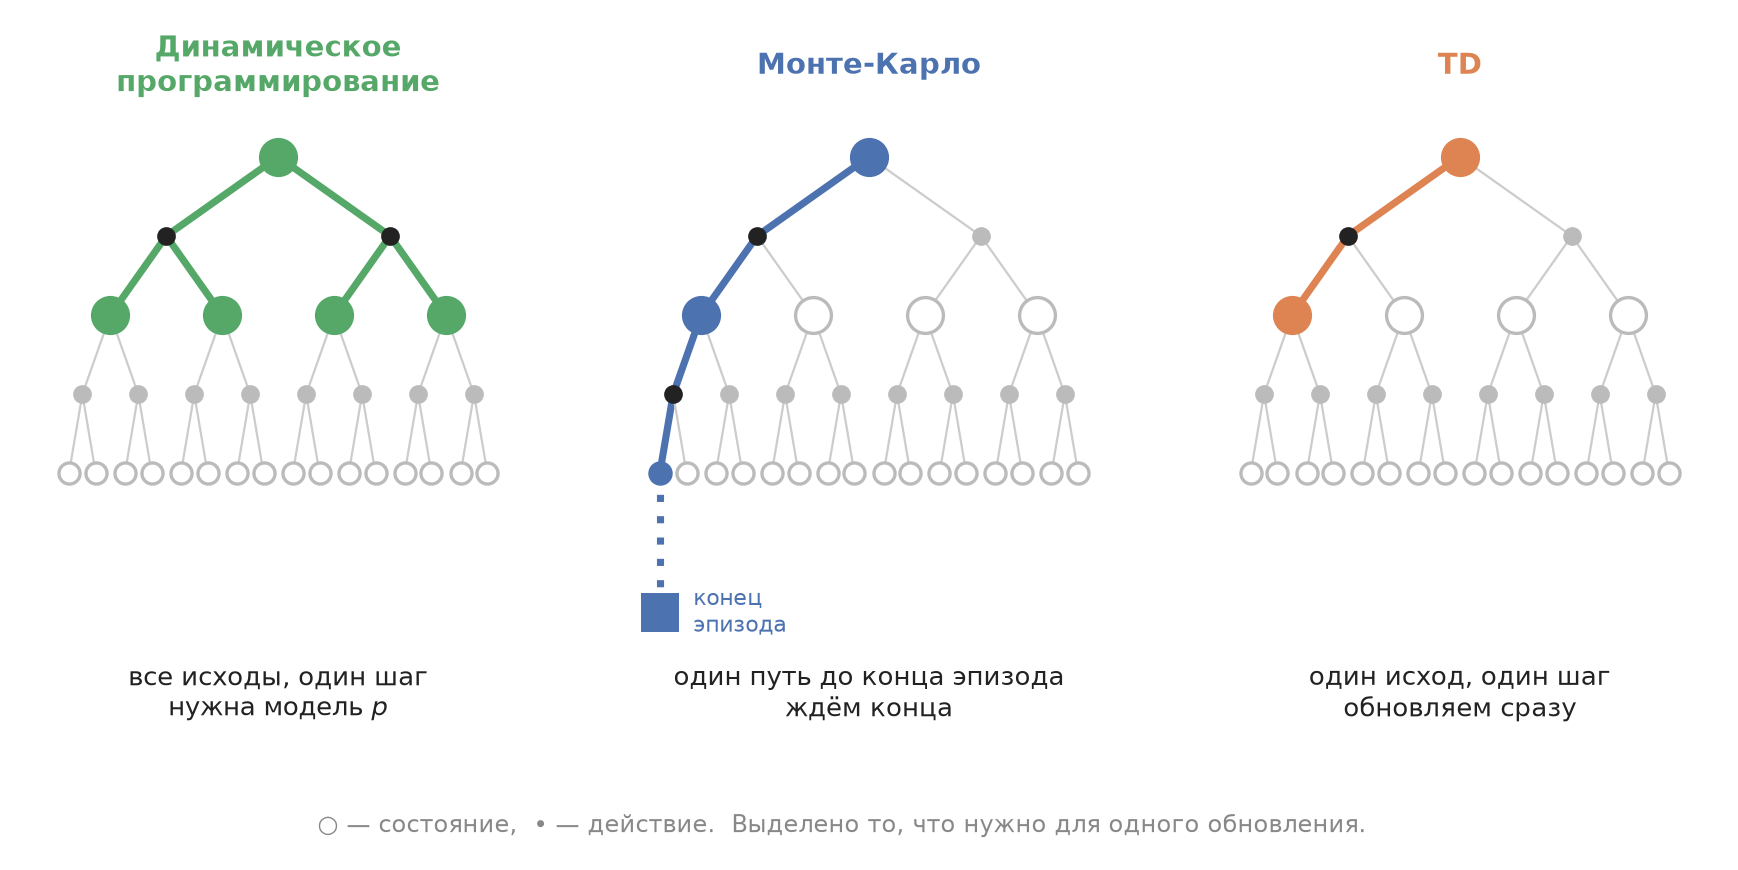

**Одной строкой:** TD — уравнение Беллмана для $\pi$, где среднее по исходам заменено одним шагом, а присваивание — средним на ходу.

## 6. Q-learning

🔁 Лекция 2, раздел 4 — уравнение оптимальности, которое решал value iteration:

$$
Q^*(s,a) = \sum_{s'} p(s' \mid s,a)\,\big[\,r + \gamma \max_{a'} Q^*(s',a')\,\big]
$$

Сделаем с ним то же, что в разделе 5: сумму по $s'$ заменим одним переходом из `env.step`, присваивание — средним на ходу.

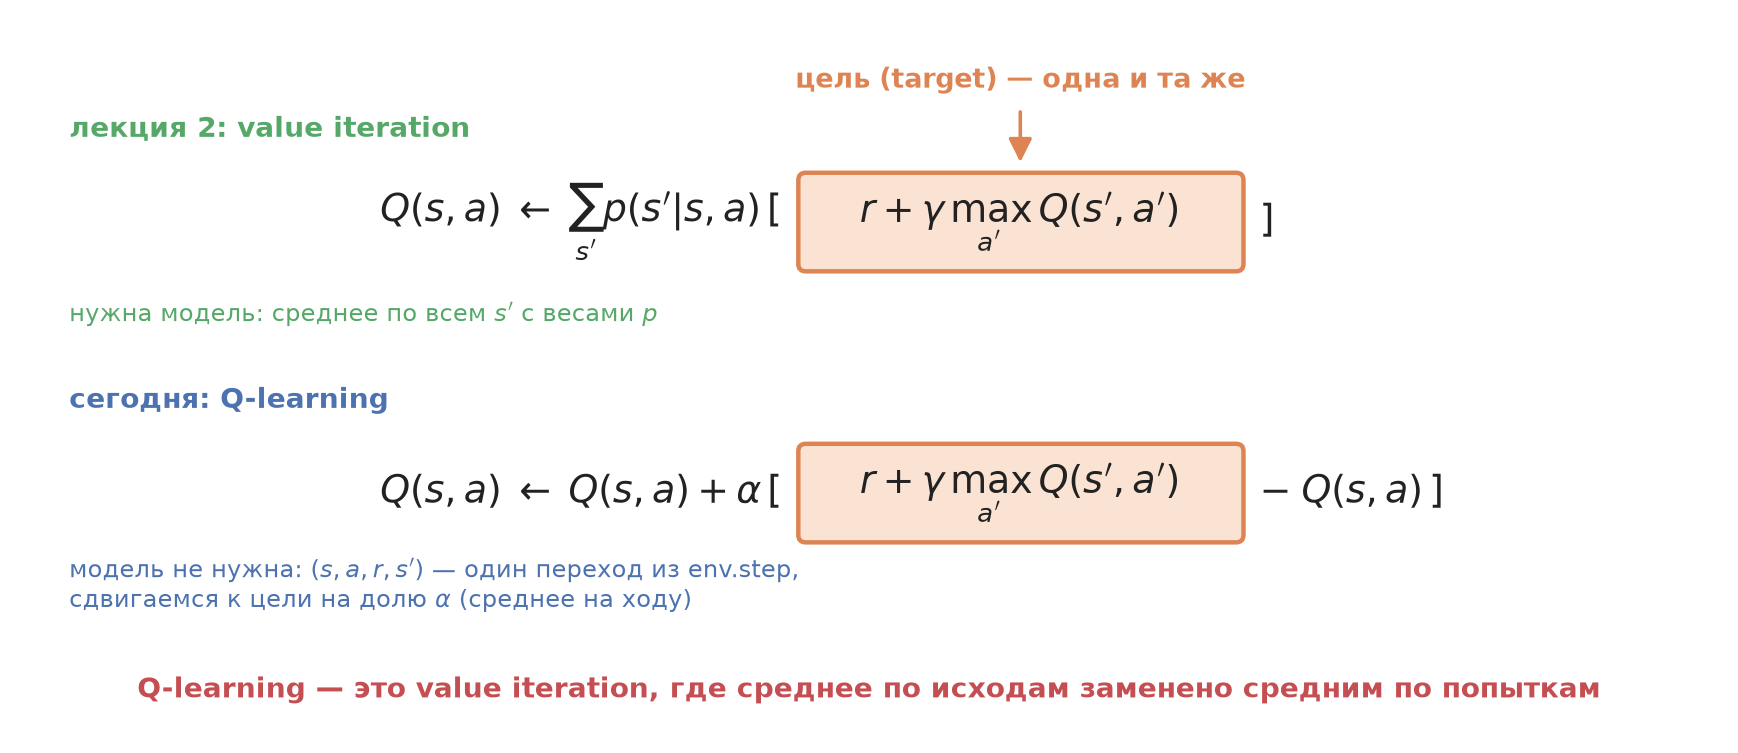

### 6.1 Одна клетка: среднее по попыткам вместо среднего по вероятностям

Посмотрим на главную замену в действии. Возьмём одну пару — старт, действие ↑ — и 300 раз сделаем из неё один шаг. Чтобы следить только за этой клеткой, оценки соседей считаем уже верными: возьмём $V^*$ из лекции 2. Каждый раз ветер даёт свой исход, и цель $r + \gamma V^*(s')$ получается своя. К чему придёт среднее на ходу?

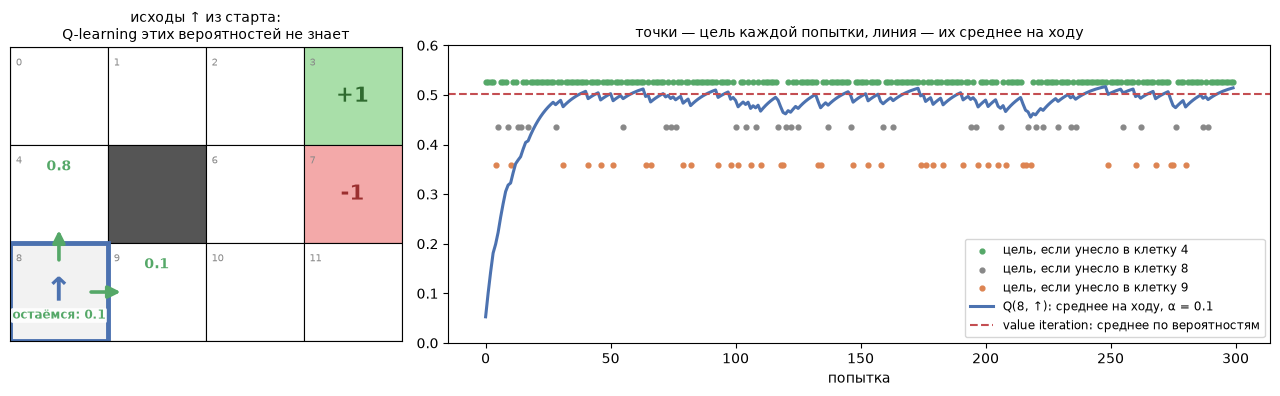

унесло в клетку 4: цель +0.53,  частота 0.75  (вероятность в модели 0.8)
унесло в клетку 8: цель +0.44,  частота 0.12  (вероятность в модели 0.1)
унесло в клетку 9: цель +0.36,  частота 0.13  (вероятность в модели 0.1)
среднее на ходу, последние 100 попыток: +0.49;   value iteration: +0.50


In [11]:
s, a, alpha = 8, 3, 0.1                               # старт, действие ↑, шаг среднего на ходу
q, targets, history, outcomes = 0.0, [], [], []
for i in range(300):
    env.reset(seed=i)
    s_next, r, *_ = env.step(a)                       # одна попытка: исход выбирает ветер
    target = r + GAMMA * V_star[s_next]               # цель — своя на каждой попытке
    q += alpha * (target - q)                         # среднее на ходу (раздел 4)
    outcomes.append(s_next); targets.append(target); history.append(q)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.9), gridspec_kw={"width_ratios": [1, 2.1]})
draw_transitions(env, s=8, a=3, ax=axes[0], title="исходы ↑ из старта:\nQ-learning этих вероятностей не знает")
colors = {4: "#55A868", 8: "#888888", 9: "#DD8452"}
for s_out, color in colors.items():
    idx = [i for i, o in enumerate(outcomes) if o == s_out]
    axes[1].scatter(idx, [targets[i] for i in idx], s=12, color=color, label=f"цель, если унесло в клетку {s_out}")
axes[1].plot(history, color="#4C72B0", lw=2.2, label="Q(8, ↑): среднее на ходу, α = 0.1")
axes[1].axhline(Q_star[8, 3], color="#C44E52", ls="--", lw=1.5, label="value iteration: среднее по вероятностям")
axes[1].set_xlabel("попытка"); axes[1].set_ylim(0, 0.6); axes[1].legend(fontsize=8.5, loc="lower right")
axes[1].set_title("точки — цель каждой попытки, линия — их среднее на ходу", fontsize=10)
plt.tight_layout(); plt.show()

for s_out in colors:
    print(f"унесло в клетку {s_out}: цель {targets[outcomes.index(s_out)]:+.2f},  "
          f"частота {outcomes.count(s_out) / len(outcomes):.2f}  (вероятность в модели {P[8, 3, s_out]:.1f})")
print(f"среднее на ходу, последние 100 попыток: {np.mean(history[-100:]):+.2f};   value iteration: {Q_star[8, 3]:+.2f}")

Каждая отдельная цель неверна: то +0.53, то +0.36. Но среднее на ходу держится у +0.50 — того самого числа, которое value iteration получил, взвесив исходы вероятностями: $0.8 \cdot 0.53 + 0.1 \cdot 0.44 + 0.1 \cdot 0.36 = 0.50$. Вероятности модели не понадобились: они «сидят» в том, как часто выпадает каждый исход.

В настоящем Q-learning оценки соседей не даны заранее, а учатся одновременно с этой. Так устроен алгоритм в 6.3.

### 6.2 Кто выбирает действия: ε-жадность

🔁 Лекция 1, раздел 10: исследование и использование — пойти в проверенное кафе или попробовать новое. Агент учится на своих же действиях: если всегда делать лучшее по нынешним оценкам, про остальные действия он так ничего и не узнает. Простейший компромисс — **ε-жадная** стратегия.

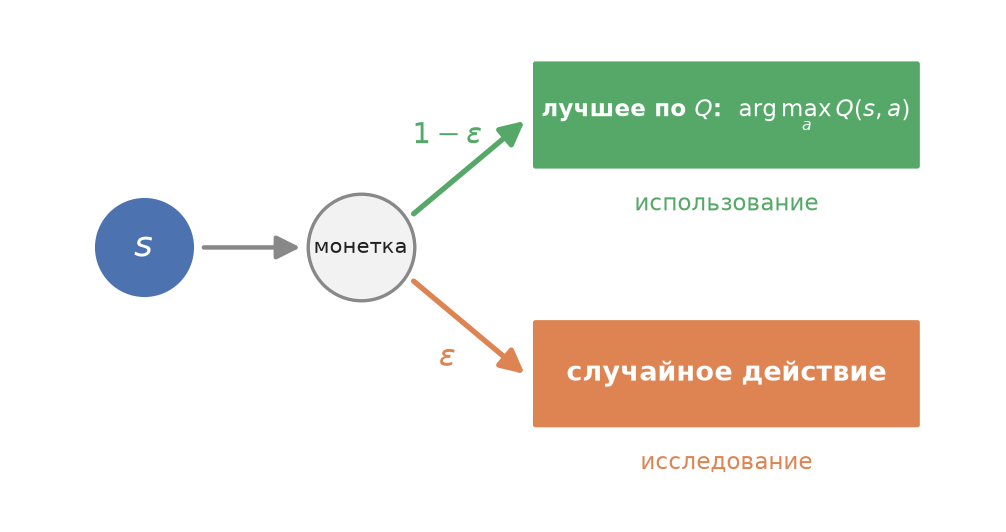

In [12]:
def epsilon_greedy(Q, s, eps, rng):
    """С вероятностью ε — случайное действие, иначе лучшее по Q."""
    if rng.random() < eps:
        return int(rng.integers(Q.shape[1]))
    return int(rng.choice(np.flatnonzero(Q[s] == Q[s].max())))   # ничьи — случайно: в начале все Q равны нулю

### 6.3 Алгоритм целиком

Шаблон обновления, ε-жадный выбор действий и цикл по эпизодам — это весь Q-learning.

In [13]:
def q_learning(env, n_episodes, alpha=0.1, eps=0.2, gamma=GAMMA, seed=0, max_steps=100):
    rng = np.random.default_rng(seed)
    Q = np.zeros((env.n_states, env.n_actions))
    for episode in range(n_episodes):
        s, _ = env.reset(seed=int(rng.integers(1_000_000)))
        for t in range(max_steps):
            a = epsilon_greedy(Q, s, eps, rng)                     # действие выбирает ε-жадная стратегия
            s_next, r, terminated, truncated, _ = env.step(a)      # среда показывает один исход
            future = 0.0 if terminated else Q[s_next].max()        # у терминальной клетки будущего нет
            target = r + gamma * future                            # цель: правая часть уравнения Беллмана
            Q[s, a] += alpha * (target - Q[s, a])                  # среднее на ходу
            s = s_next
            if terminated or truncated:
                break
    return Q

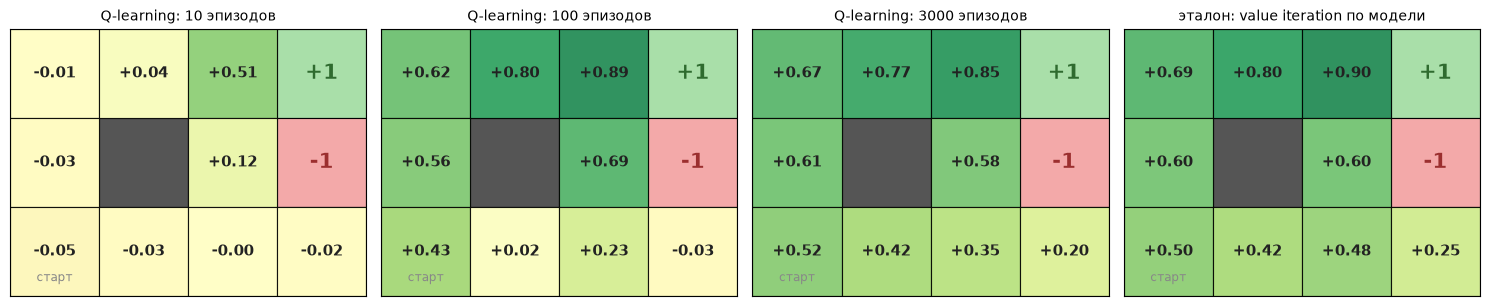

In [14]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.3))
for ax, n in zip(axes, [10, 100, 3000]):
    plot_values(q_learning(env, n).max(axis=1), env, ax=ax, title=f"Q-learning: {n} эпизодов")
plot_values(V_star, env, ax=axes[3], title="эталон: value iteration по модели")
plt.tight_layout(); plt.show()

Знакомая картина 🔁: ценность расходится от выхода волной, как в value iteration (лекция 2, раздел 4.2). Только там волна шла по итерациям уравнения, а здесь — по сыгранным эпизодам.

Сравним результат с эталоном.

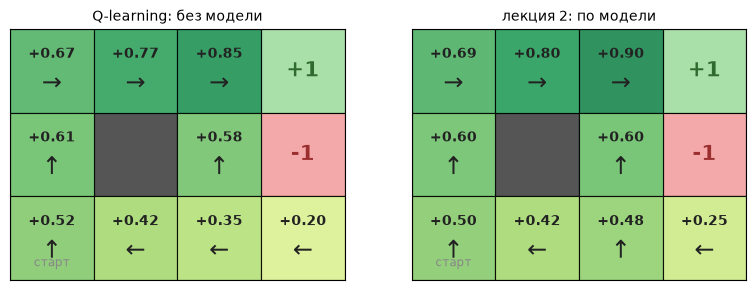

V(старт): Q-learning +0.523,  точно +0.501


средний return жадной стратегии: Q-learning +0.51,  оптимальная +0.50
клетки, где стрелки разошлись: [10]


In [15]:
Q_ql = q_learning(env, 3000)

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.6))
draw_policy(greedy_policy(Q_ql), env, ax=axes[0], values=Q_ql.max(axis=1), title="Q-learning: без модели")
draw_policy(greedy_policy(Q_star), env, ax=axes[1], values=V_star, title="лекция 2: по модели")
plt.show()

rng = np.random.default_rng(0)
print(f"V(старт): Q-learning {Q_ql[env.start].max():+.3f},  точно {V_star[env.start]:+.3f}")
print(f"средний return жадной стратегии: Q-learning {average_return(env, greedy_policy(Q_ql), rng):+.2f},  "
      f"оптимальная {average_return(env, greedy_policy(Q_star), rng):+.2f}")
print("клетки, где стрелки разошлись:", [s for s in CELLS if Q_ql[s].argmax() != Q_star[s].argmax()])

Ни разу не заглянув в `P` и `R`, Q-learning нашёл ту же стратегию: средний return +0.51 против +0.50 у оптимальной — разница в пределах шума. Стрелки разошлись только в клетке 10. Туда стратегия почти не заходит (из клетки 9 она уходит влево), и данных об этой клетке мало: агент учится там, где ходит. $V$(старт) получилось +0.52 вместо +0.50 — при постоянном $\alpha$ оценки дрожат вокруг ответа на пару сотых.

**Одной строкой:** Q-learning — это value iteration по попыткам: цель $r + \gamma \max_{a'} Q(s',a')$, сдвиг на долю $\alpha$.

## 7. SARSA и прогулка по обрыву

В цели Q-learning стоит $\max_{a'}$ — «дальше я сыграю идеально». Но учится агент ε-жадно и иногда делает случайный шаг. **SARSA** подставляет в цель то действие $a'$, которое агент действительно сделает:

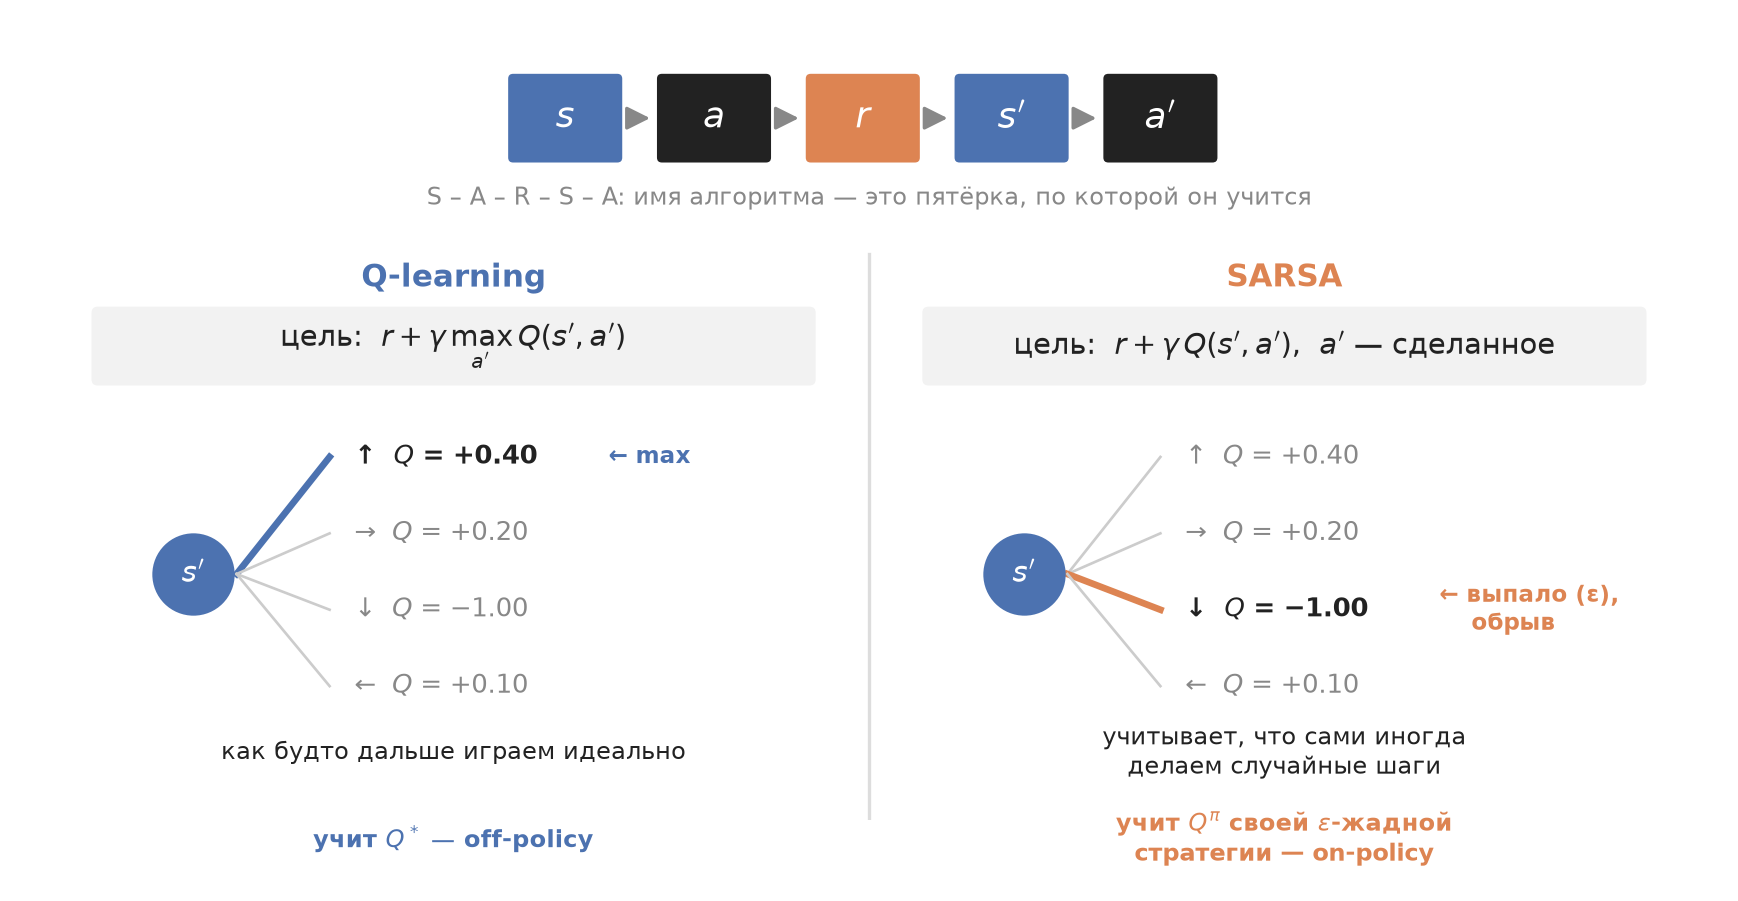

🔁 Это то же отличие, что между двумя уравнениями лекции 2: Q-learning решает уравнение оптимальности (максимум), SARSA — уравнение для стратегии $\pi$ (усреднение), где $\pi$ — сама ε-жадная стратегия агента.

### 7.1 Прогулка по обрыву

Когда это важно? Классический пример — **прогулка по обрыву** (Cliff Walking из Gymnasium). Поле 4 × 12, старт слева внизу, выход справа внизу, между ними обрыв. Шаг стоит −1, падение — −100 и возврат на старт.

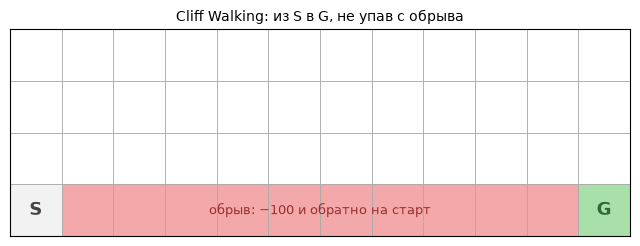

In [16]:
draw_cliff(title="Cliff Walking: из S в G, не упав с обрыва"); plt.show()

Q-learning, SARSA и Expected SARSA (раздел 8) удобно держать в одной функции: они отличаются одной строкой — что подставить вместо будущего.

In [17]:
def td_control(env, kind, n_episodes=500, alpha=0.5, eps=0.1, gamma=1.0, seed=0, max_steps=500):   # γ = 1: эпизод конечный, дисконт не нужен
    """Q-learning, SARSA и Expected SARSA для среды Gymnasium с дискретными состояниями."""
    rng = np.random.default_rng(seed)
    Q = np.zeros((env.observation_space.n, env.action_space.n))
    returns = []
    for episode in range(n_episodes):
        s, _ = env.reset(seed=int(rng.integers(1_000_000)))
        a = epsilon_greedy(Q, s, eps, rng)
        total = 0.0
        for t in range(max_steps):
            s_next, r, terminated, truncated, _ = env.step(a)
            a_next = epsilon_greedy(Q, s_next, eps, rng)       # следующее действие выбираем сразу
            if kind == "q-learning":
                future = Q[s_next].max()                       # как будто дальше играем идеально
            elif kind == "sarsa":
                future = Q[s_next, a_next]                     # то, что сделаем на самом деле
            else:                                              # "expected sarsa" — раздел 8
                probs = np.full(env.action_space.n, eps / env.action_space.n)
                probs[Q[s_next].argmax()] += 1 - eps
                future = probs @ Q[s_next]                     # среднее по ε-жадной стратегии
            Q[s, a] += alpha * (r + gamma * (0.0 if terminated else future) - Q[s, a])
            total += r
            s, a = s_next, a_next
            if terminated or truncated:
                break
        returns.append(total)
    return Q, np.array(returns)

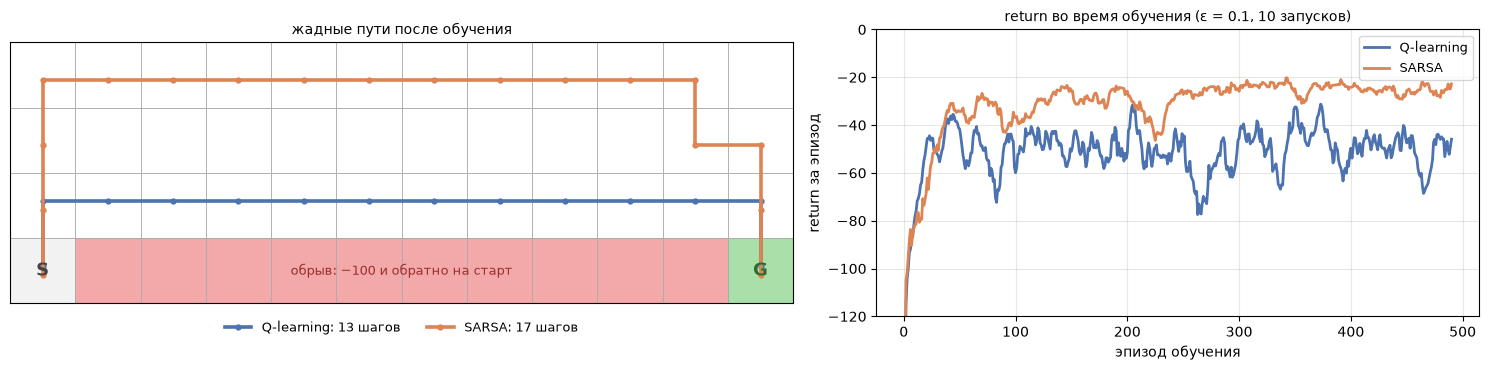

Q-learning: жадный путь доходит до G в 10 запусках из 10, длина 13 шагов; return при обучении (последние 100 эпизодов) -50.2
     SARSA: жадный путь доходит до G в 8 запусках из 10, длина 17 шагов; return при обучении (последние 100 эпизодов) -25.3


In [18]:
cliff = gym.make("CliffWalking-v1")
runs = {"Q-learning": [td_control(cliff, "q-learning", seed=seed) for seed in range(10)],
        "SARSA": [td_control(cliff, "sarsa", seed=seed) for seed in range(10)]}

SHOW = 2                                              # какой из десяти запусков нарисовать
fig, axes = plt.subplots(1, 2, figsize=(15, 3.8), gridspec_kw={"width_ratios": [1.3, 1]})
draw_cliff({name: greedy_path(r[SHOW][0]) for name, r in runs.items()}, ax=axes[0], title="жадные пути после обучения")
plot_curves({name: [ret for _, ret in r] for name, r in runs.items()}, ax=axes[1],
            title="return во время обучения (ε = 0.1, 10 запусков)")
plt.tight_layout(); plt.show()
for name, r in runs.items():
    paths = [greedy_path(Q) for Q, _ in r]
    reached = [len(p) - 1 for p in paths if p[-1] == CLIFF_GOAL]
    print(f"{name:>10}: жадный путь доходит до G в {len(reached)} запусках из 10, длина {min(reached) if min(reached) == max(reached) else f'{min(reached)}–{max(reached)}'} шагов; "
          f"return при обучении (последние 100 эпизодов) {np.mean([ret[-100:].mean() for _, ret in r]):+.1f}")

Два разных ответа на вопрос «как правильно»:

* **Q-learning** выучил кратчайший путь по самому краю — 13 шагов. Для агента без ошибок он лучший. Но учится агент ε-жадно, и случайный шаг время от времени сбрасывает его в обрыв: return при обучении около −50.
* **SARSA** выучил обход по верхнему ряду — 17 шагов. Он длиннее, зато случайный шаг там не страшен: return при обучении около −25, вдвое лучше.

В двух запусках из десяти жадная стратегия SARSA где-то упирается в стену: при постоянном $\alpha = 0.5$ её оценки дрожат. Помогает со временем уменьшать $\alpha$ или $\varepsilon$.

Кто прав? Зависит от вопроса. Если после обучения случайность выключат — лучше путь Q-learning. Если агент и дальше будет иногда ошибаться (скажем, робот с неточными моторами) — путь SARSA.

### 7.2 On-policy и off-policy: две роли стратегии

На обрыве оба агента **ходили одинаково** — ε-жадно, с одним и тем же ε. А выучили разное. Значит, у стратегии в обучении две роли:

* **стратегия поведения** — та, что ходит по среде и собирает переходы $(s, a, r, s')$;
* **целевая стратегия** — та, чью ценность мы учим. Она спрятана в цели обновления: какое действие подставляем в $s'$.

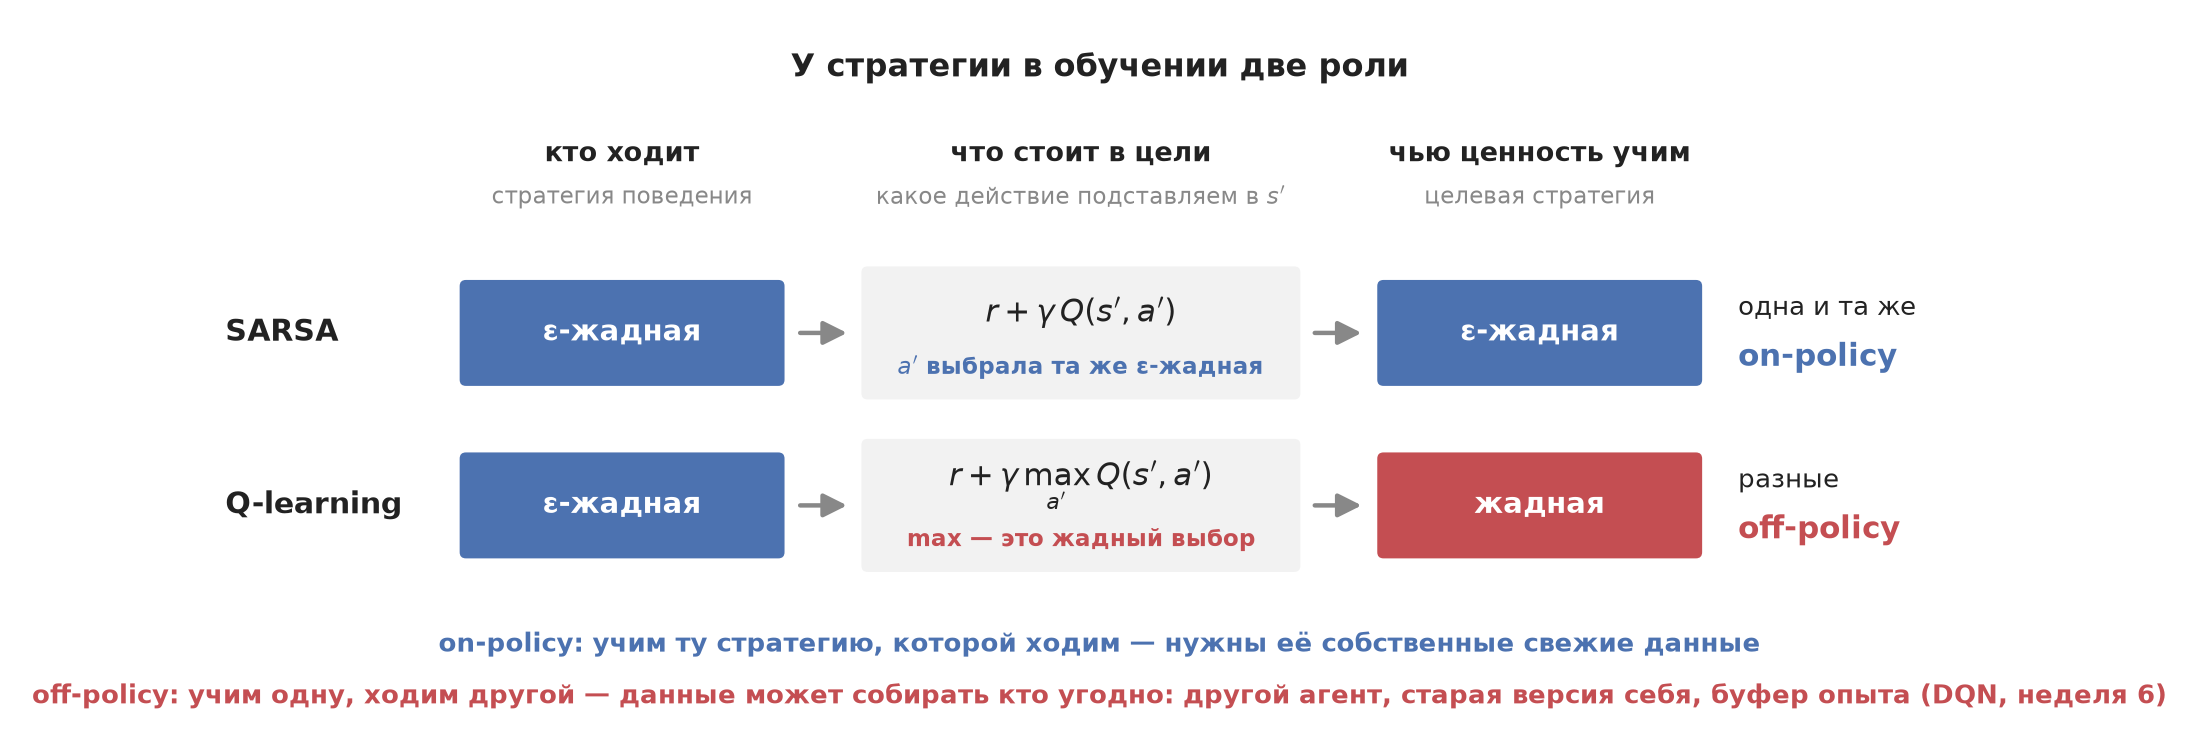

Роли совпали — алгоритм **on-policy**. Разошлись — **off-policy**.

Житейский пример. Шахматист разбирает свою вчерашнюю партию, сыгранную с ошибками. Можно спросить: «чем кончится эта позиция, если я и дальше буду играть как играю, с зевками?» — это on-policy. А можно: «чем она кончится при лучшей игре?» — это off-policy: партия сыграна одной стратегией, а оцениваем другую.

Проверим на клетчатом мире самым жёстким способом. Пусть данные собирает **чистый кубик** — ε = 1, все действия случайные. Что выучит каждый алгоритм?

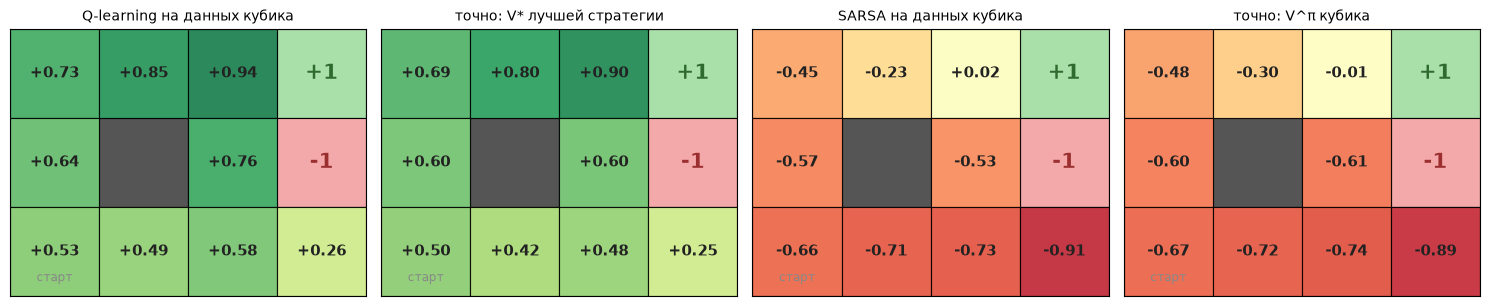

Q-learning: V(старт) = +0.53   точное V* лучшей стратегии: +0.50
SARSA:      V(старт) = -0.66   точное V^π кубика:        -0.67


In [19]:
# клетчатому миру из лекции 2 добавляем два поля в стиле Gymnasium — чтобы td_control его понимал
env.observation_space, env.action_space = gym.spaces.Discrete(env.n_states), gym.spaces.Discrete(env.n_actions)

dice = dict(n_episodes=3000, alpha=0.05, eps=1.0, gamma=GAMMA, max_steps=100)   # ε = 1: ходит чистый кубик
Q_off, _ = td_control(env, "q-learning", **dice)
Q_on, _ = td_control(env, "sarsa", **dice)
V_off = Q_off.max(axis=1)                     # Q-learning учит жадную стратегию: её ценность — максимум по действиям
V_on = (uniform * Q_on).sum(axis=1)           # SARSA учит того, кто ходит, — кубик: его ценность — среднее по действиям

fig, axes = plt.subplots(1, 4, figsize=(15, 3.3))
plot_values(V_off, env, ax=axes[0], title="Q-learning на данных кубика")
plot_values(V_star, env, ax=axes[1], title="точно: V* лучшей стратегии")
plot_values(V_on, env, ax=axes[2], title="SARSA на данных кубика")
plot_values(V_true, env, ax=axes[3], title="точно: V^π кубика")
plt.tight_layout(); plt.show()
print(f"Q-learning: V(старт) = {V_off[env.start]:+.2f}   точное V* лучшей стратегии: {V_star[env.start]:+.2f}")
print(f"SARSA:      V(старт) = {V_on[env.start]:+.2f}   точное V^π кубика:        {V_true[env.start]:+.2f}")

Ходил в обоих случаях кубик, а выучено разное:

* **Q-learning** выучил ценность **лучшей** стратегии: из старта +0.53 при точном +0.50 — хотя ни одного жадного шага сделано не было. Числа немного завышены; это свойство максимума, о нём ⏱ раздел 8.2.
* **SARSA** выучил ценность **того, кто ходил**, — кубика: −0.66 при точном −0.67.

Что из этого следует на практике:

* off-policy-алгоритм может учиться на чужих и старых данных. На этом построен буфер опыта в DQN (неделя 6);
* on-policy-алгоритму нужны свежие данные его собственной стратегии: стратегия изменилась — старые данные уже не про неё. Так устроены policy gradient и PPO (недели 7–9).

Теперь понятен и обрыв. SARSA оценивал свою ε-жадную стратегию вместе с её случайными шагами — и ушёл от края. Q-learning оценивал жадную стратегию, которая не оступается, — и пошёл по краю.

**Одной строкой:** Q-learning учит ценность жадной стратегии, кто бы ни собирал данные (off-policy); SARSA учит ценность той стратегии, которая ходит (on-policy).

## 8. ⏱ Expected SARSA и Double Q-learning

### 8.1 Expected SARSA

SARSA берёт одно случайное $a'$, и это лишний шум. Можно усреднить по всем действиям с их вероятностями:

$$
\text{цель} = r + \gamma \sum_{a'} \pi(a' \mid s')\, Q(s', a')
$$

🔁 Это ровно связь $V^\pi(s') = \sum_{a'} \pi(a' \mid s')\, Q^\pi(s', a')$ из лекции 2, раздел 3.1. В коде — третья ветка `td_control`.

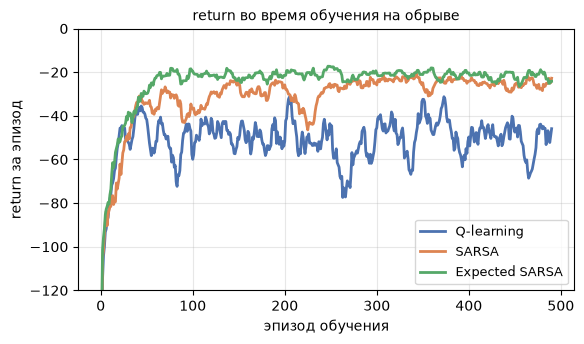

    Q-learning: return при обучении, последние 100 эпизодов: -50.2
         SARSA: return при обучении, последние 100 эпизодов: -25.3
Expected SARSA: return при обучении, последние 100 эпизодов: -21.9


In [20]:
runs["Expected SARSA"] = [td_control(cliff, "expected sarsa", seed=seed) for seed in range(10)]
plot_curves({name: [ret for _, ret in r] for name, r in runs.items()}, title="return во время обучения на обрыве")
plt.show()
for name, r in runs.items():
    print(f"{name:>14}: return при обучении, последние 100 эпизодов: {np.mean([ret[-100:].mean() for _, ret in r]):+.1f}")

Expected SARSA при обучении набирает больше всех — около −22. Цель у него та же, что у SARSA, только без лишнего шума от случайного $a'$.

### 8.2 Double Q-learning: максимум завышает

Простой пример. Десять игровых автоматов, у **всех** средний выигрыш ровно 0. Сыграем на каждом по 10 раз и спросим: сколько даёт лучший автомат?

In [21]:
rng = np.random.default_rng(0)
wins = rng.normal(0, 1, size=(10_000, 10, 10))       # 10 000 повторов опыта: 10 автоматов × 10 игр

Q_one = wins.mean(axis=2)                              # одна оценка по всем играм
Q_A, Q_B = wins[..., :5].mean(axis=2), wins[..., 5:].mean(axis=2)   # две независимые оценки по половинам
best_by_A = Q_A.argmax(axis=1)

print(f"одна таблица:  max_a Q(a)          = {Q_one.max(axis=1).mean():+.2f}   (истина 0)")
print(f"две таблицы:   Q_B(argmax_a Q_A(a)) = {round(Q_B[np.arange(len(Q_B)), best_by_A].mean(), 2) + 0.0:+.2f}")

одна таблица:  max_a Q(a)          = +0.49   (истина 0)
две таблицы:   Q_B(argmax_a Q_A(a)) = +0.00


Максимум шумных оценок систематически больше нуля: среди десяти автоматов всегда найдётся «везунчик». В Q-learning такой максимум стоит в каждой цели, и завышение накапливается. Лекарство — две таблицы: одна **выбирает** действие, другая его **оценивает**:

$$
\text{цель} = r + \gamma\, Q_B\big(s',\ \arg\max_{a'} Q_A(s', a')\big)
$$

На каждом шаге случайно решаем, какую из таблиц обновлять, и они меняются ролями. Это **Double Q-learning**. На неделе 6 та же идея станет Double DQN.

## 9. Итоги

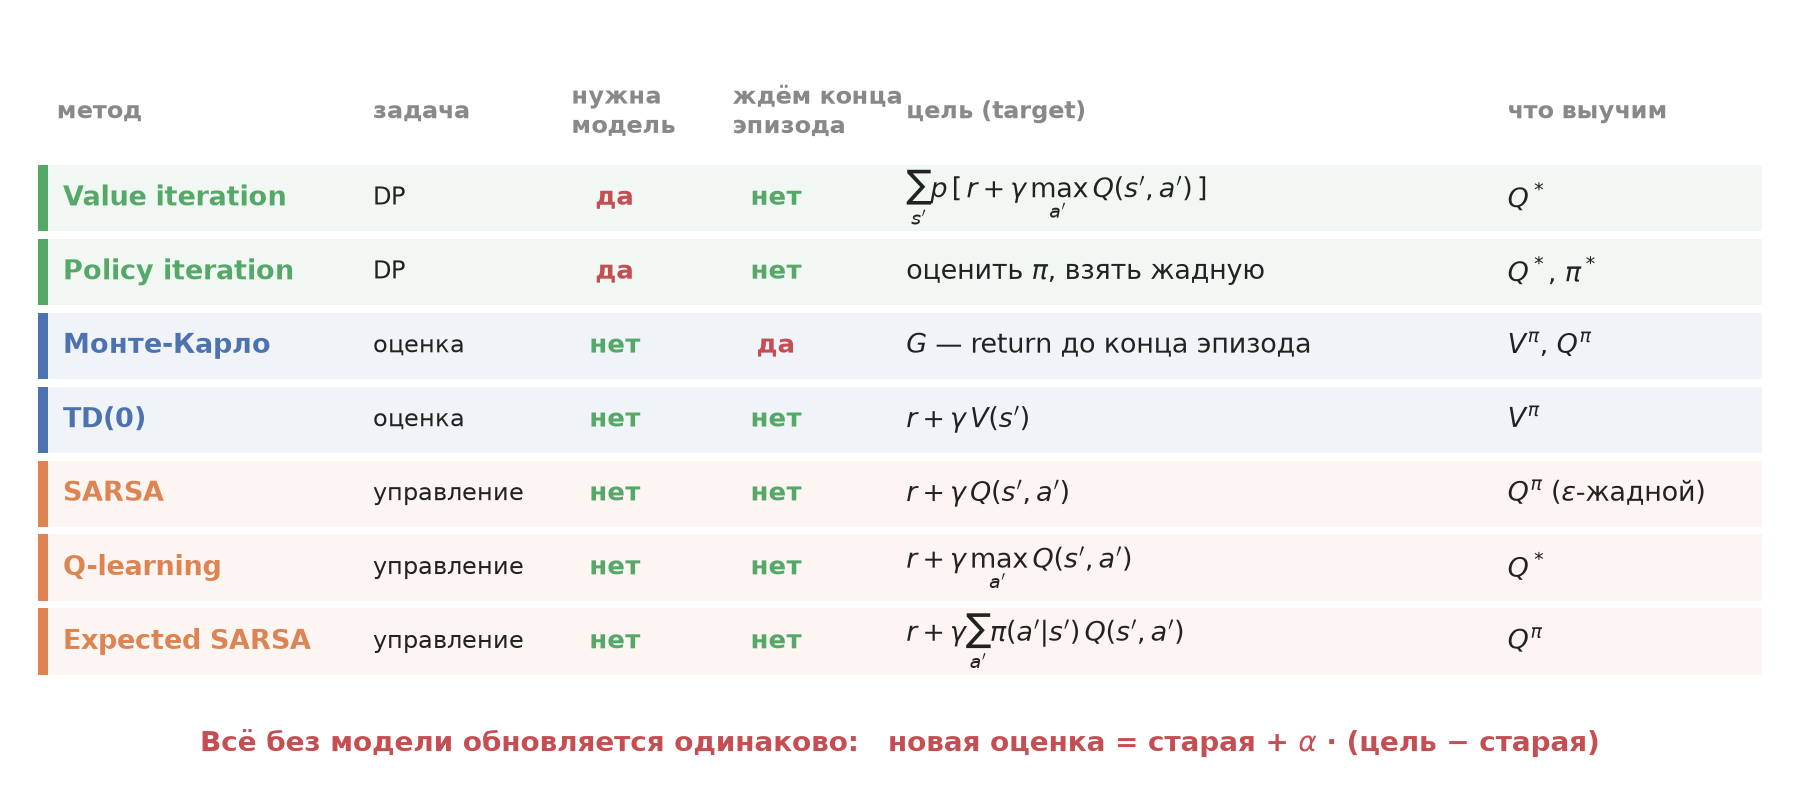

1. **Нет модели — среднее по исходам заменяют средним по попыткам**, а среднее считают на ходу: новая оценка = старая + $\alpha$ · (цель − старая).
2. **Монте-Карло** берёт целью фактический return: честно, но шумно и только после конца эпизода. **TD** берёт $r + \gamma V(s')$: учится после каждого шага, ценой смещения.
3. **Q-learning** — value iteration по попыткам: цель $r + \gamma \max_{a'} Q(s',a')$. Учит $Q^*$, даже когда действует ε-жадно (off-policy).
4. **SARSA** подставляет действие, которое агент сделает на самом деле, и учит ценность своей ε-жадной стратегии (on-policy). На обрыве это безопасный путь вместо кратчайшего.
5. **Действовать надо с исследованием**, например ε-жадно: иначе часть действий так и останется неопробованной.
6. 🔁 Под всем этим — уравнение Беллмана из лекции 2. DP решает его по модели, сегодняшние методы — по опыту.

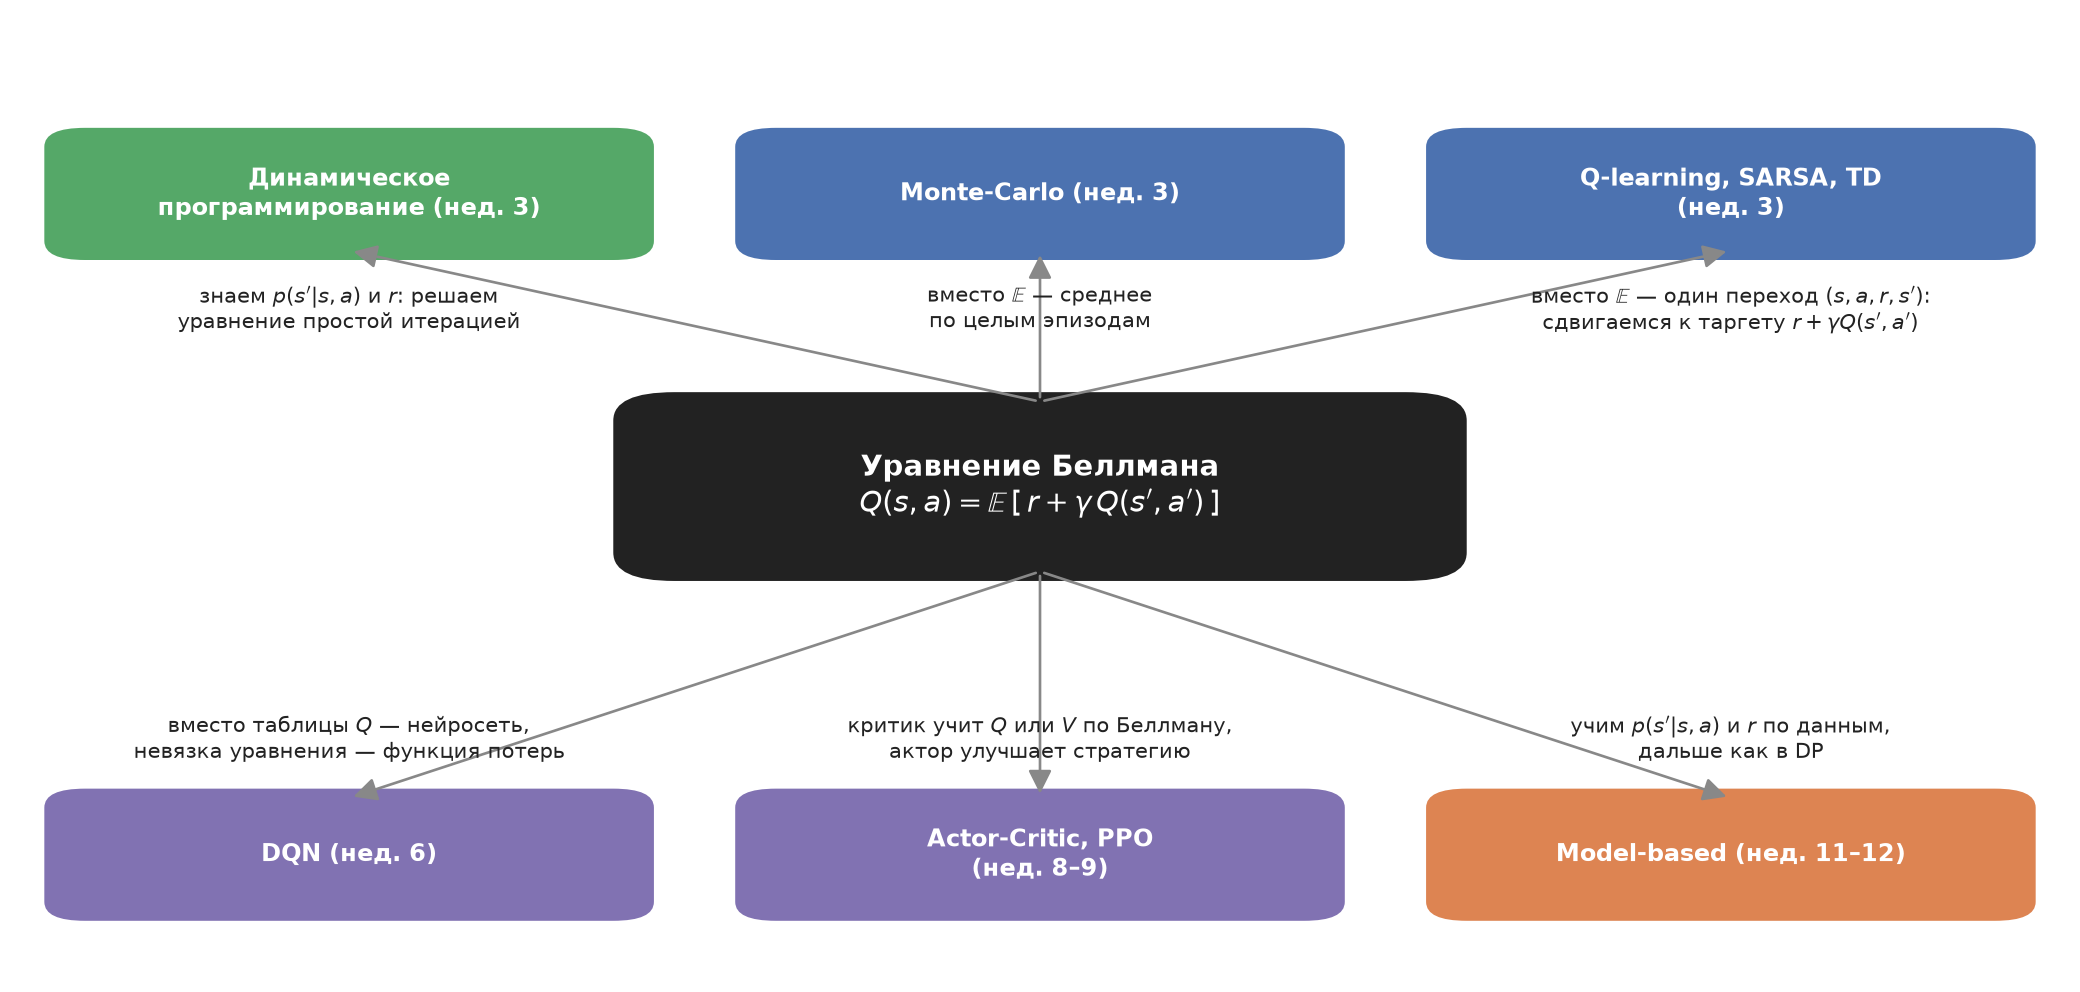

Сегодня мы прошли верхний ряд этой картинки. Дальше таблица $Q$ перестанет помещаться в память: на неделе 5 её заменит нейросеть, на неделе 6 — DQN, то есть Q-learning с нейросетью. А неделя 4 — про другой путь: учить саму стратегию, вообще без $Q$.

Словарь лекции: **policy iteration, среднее на ходу и шаг обучения $\alpha$, Монте-Карло-оценка, TD-обучение, TD-цель, TD-ошибка, смещение и шум, Q-learning, ε-жадная стратегия, SARSA, on-policy и off-policy, Expected SARSA, Double Q-learning**.

## Литература

* R. Sutton, A. Barto. *Reinforcement Learning: An Introduction* — [бесплатный PDF](http://incompleteideas.net/book/the-book-2nd.html). Глава 4 — policy iteration и value iteration; глава 5 — Монте-Карло; глава 6 — TD, SARSA, Q-learning, Expected SARSA и Double Q-learning. Там же пример «дорога домой» (6.1) и обрыв (6.5).
* [Учебник по машинному обучению ШАД, глава «Обучение с подкреплением»](https://education.yandex.ru/handbook/ml/article/obuchenie-s-podkrepleniem) — раздел про Q-learning.
* D. Silver. [UCL Course on RL](https://www.davidsilver.uk/teaching/), лекции 4 (model-free prediction) и 5 (model-free control).
* [Понимание Q-learning, проблема «Прогулка по скале»](https://habr.com/ru/articles/443240/) — Хабр, тот же обрыв с анимацией.
* [TD-обучение в браузере](https://cs.stanford.edu/people/karpathy/reinforcejs/gridworld_td.html) — клетчатый мир, можно смотреть, как Q-learning заполняет таблицу.

## На семинаре и дома

* **Семинар**: policy iteration, SARSA и Q-learning своими руками — на обрыве и в Taxi.
* **Квиз** по лекции 3 — на [странице квизов](https://ilyachichkanov.github.io/Reinforcement-learning/).
* **Домашнее задание блока 2** выдаётся после лекции 4 и охватывает обе лекции блока.
* **Неделя 4**: policy-based методы — учим саму стратегию, без таблицы $Q$.